In [82]:
# ==============================================================
# CELL 1 – Imports, Hardware Setup & Drive Mount
# ==============================================================
import sys, os, random
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)

# Set Global Seed for total reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use: {device}')
print(f'PyTorch version: {torch.__version__}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device in use: cuda
PyTorch version: 2.10.0+cu128


In [83]:
import numpy as np

# 1. Path of the processed .npz file
PATH_NPZ = '/content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/IBD_1000pt_FingerPrint.npz'

print(f'Loading processed data from {PATH_NPZ}...')

data = np.load(PATH_NPZ)
print("Variables found in the .npz:", list(data.keys()))

# Estrazione diretta sapendo le chiavi esatte
X_data = data['spectra'].astype(np.float32)
Y_data = data['labels'].flatten().astype(np.int64)

# Fix shape if needed (now for 1000 points)
if X_data.shape[0] == 1000 and X_data.shape[1] == len(Y_data):
    X_data = X_data.T

N, L = X_data.shape
print("-" * 40)
print(f'Usable spectra : {N}')
print(f'Spectral points: {L}')
print(f'HC (0)         : {(Y_data==0).sum()}')
print(f'IBD (1)        : {(Y_data==1).sum()}')
print(f'X shape        : {X_data.shape}')
print(f'Y shape        : {Y_data.shape}')


Loading processed data from /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/IBD_1000pt_FingerPrint.npz...
Variables found in the .npz: ['spectra', 'wavelengths', 'labels', 'groups']
----------------------------------------
Usable spectra : 228
Spectral points: 1000
HC (0)         : 93
IBD (1)        : 135
X shape        : (228, 1000)
Y shape        : (228,)


In [84]:
# ==============================================================
# CELL 3 – Import SpectraMAENet & Load Foundation Weights
# ==============================================================
import subprocess
import sys
import os
import torch

REPO_PATH  = '/content/SpectraMAENet'
MODEL_PATH = os.path.join(REPO_PATH, 'model')

if not os.path.exists(REPO_PATH):
    print("Cloning SpectraMAENet repository...")
    subprocess.run(['git', 'clone', 'https://github.com/pengjuRen99/SpectraMAENet.git', REPO_PATH], check=True)

init_file = os.path.join(MODEL_PATH, '__init__.py')
if not os.path.exists(init_file):
    open(init_file, 'w').close()

for p in [REPO_PATH, MODEL_PATH]:
    if p in sys.path: sys.path.remove(p)
sys.path.insert(0, REPO_PATH)

from model.Spectra_MAE import MaskedAutoencoderViT

# --- Hyperparameters (MANDATORY: Must match Pre-Training perfectly!) ---
SPECTRA_SIZE   = 1000
PATCH_SIZE     = 100
ENCODER_DIM    = 256
ENCODER_DEPTH  = 8
ENCODER_HEADS  = 8
DIM_MLP        = 512   # 2 * ENCODER_DIM
DECODER_DIM    = 128
DECODER_DEPTH  = 1# Changed from 2 to 1 to match expected pre-trained model architecture
DECODER_HEADS  = 8  # CORRECT: 8 heads!

def build_smae_encoder():
    """Builds the MAE Architecture."""
    return MaskedAutoencoderViT(
        spectra_size      = SPECTRA_SIZE,
        patch_size        = PATCH_SIZE,
        encoder_dim       = ENCODER_DIM,
        depth             = ENCODER_DEPTH,
        num_heads         = ENCODER_HEADS,
        dim_mlp           = DIM_MLP,
        decoder_embed_dim = DECODER_DIM,
        decoder_depth     = DECODER_DEPTH,
        decoder_num_heads = DECODER_HEADS,
        norm_pix_loss     = False,
    ).to(device)

# CHANGE THIS to point to the .pth file generated by your Pre-Training Notebook
PATH_PRETRAINED = '/content/drive/MyDrive/Tesi_Raman/Models/PreTrain/SMAE/1000_pt/FingerPrint/Min-Max/exp_9/smae_pretrained_model.pth'

print("Loading pre-trained Foundation Model...")
foundation_model = build_smae_encoder()
foundation_model.load_state_dict(torch.load(PATH_PRETRAINED, map_location=device))
foundation_model.eval()

print(f'✅ Foundation Model loaded successfully from: {PATH_PRETRAINED}')


Loading pre-trained Foundation Model...
✅ Foundation Model loaded successfully from: /content/drive/MyDrive/Tesi_Raman/Models/PreTrain/SMAE/1000_pt/FingerPrint/Min-Max/exp_9/smae_pretrained_model.pth


In [85]:
# ==============================================================
# CELL 4 – Classification Model Architecture (Encoder + Head)
# ==============================================================
import torch.nn as nn



class SMAEClassifier(nn.Module):
    """
    Takes the pre-trained SMAE Encoder and attaches an MLP Classification Head.
    Includes methods to freeze/unfreeze the encoder for the LP-FT strategy.
    """
    def __init__(self, smae_model, encoder_dim, n_classes=2, head_hidden_dim=128):
        super().__init__()
        # Extract only the encoder from the MAE
        self.encoder = smae_model

        # Build the MLP Classification Head
        self.head = nn.Sequential(
            nn.LayerNorm(encoder_dim),
            nn.Linear(encoder_dim, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(0.4), # Aumentato da 0.2 a 0.4 per limitare l'overfitting
            nn.Linear(head_hidden_dim, n_classes)
        )

        # Custom initialization of head weights (e.g., He Normal)
        self._init_weights()

    def _init_weights(self):
        """Initializes the linear layers of the head using Kaiming (He) Normal."""
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                # Kaiming normal is ideal for ReLU/GELU
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Forward pass through the MAE encoder (mask_ratio=0.0 because we want the full spectrum)
        latent, _, _ = self.encoder.forward_encoder(x, mask_ratio=0.0)

        # Average pooling over the patch tokens (excluding the CLS token at index 0)
        # Reverting to average pooling as it showed far superior representation for 1D Raman spectra
        emb = latent[:, 1:, :].mean(dim=1)   # Shape: (Batch_Size, encoder_dim)

        # Pass features through the classification head
        logits = self.head(emb)
        return logits

    def freeze_encoder(self):
        """Freezes the encoder weights for Stage 1: Linear Probing."""
        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.head.parameters():
            param.requires_grad = True

    def unfreeze_encoder(self):
        """Unfreezes the encoder weights for Stage 2: Full Fine-Tuning."""
        for param in self.parameters():
            param.requires_grad = True


In [86]:
# ==============================================================
# CELL 5 – Train / Val / Test Split (70-15-15)
# ==============================================================
from sklearn.model_selection import train_test_split

# ---> CHANGE THIS VALUE TO TRY DIFFERENT SPLITS <---
SEED = 42 # Try 0, 123, 999, or None for a different split each time

# Splitting Data into 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_data, Y_data, test_size=0.30, random_state=SEED, stratify=Y_data
)

# Splitting Temp into 15% Val, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train set: {X_train.shape[0]} samples (HC: {(y_train==0).sum()}, IBD: {(y_train==1).sum()})")
print(f"Val set:   {X_val.shape[0]} samples (HC: {(y_val==0).sum()}, IBD: {(y_val==1).sum()})")
print(f"Test set:  {X_test.shape[0]} samples (HC: {(y_test==0).sum()}, IBD: {(y_test==1).sum()})")


Train set: 159 samples (HC: 65, IBD: 94)
Val set:   34 samples (HC: 14, IBD: 20)
Test set:  35 samples (HC: 14, IBD: 21)


In [87]:
# ==============================================================
# CELL 6 – LP-FT FINE-TUNING (Train / Val)
# ==============================================================
import time
import random
import torch
import copy
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
import numpy as np

# Hyperparameters
LP_EPOCHS = 50
FT_EPOCHS = 100
LP_LR = 1e-3
FT_LR = 1e-5
BATCH_SIZE = 32
PATIENCE = 30
HEAD_DIM = 256

def eval_model(model, loader):
    model.eval()
    preds, labels, probs, losses = [], [], [], []
    criterion = torch.nn.CrossEntropyLoss()
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
            probs.append(F.softmax(logits, dim=1)[:, 1].cpu())
            preds.append(logits.argmax(dim=1).cpu())
            labels.append(yb.cpu())
    return (
        torch.cat(preds).numpy(),
        torch.cat(labels).numpy(),
        torch.cat(probs).numpy(),
        np.mean(losses)
    )

# --- CUSTOM DATASET FOR ADVANCED RAMAN DATA AUGMENTATION ---
class RamanAugmentedDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_val = self.X[idx].clone()
        if self.augment:
            # 1. Random intensity multiplier (+/- 5%)
            scale = random.uniform(0.95, 1.05)
            x_val = x_val * scale

            # 2. Very light Gaussian noise to simulate instrumental noise
            noise = torch.randn_like(x_val) * 1e-4
            x_val = x_val + noise

            # 3. Random Masking (1D Cutout)
            # 50% chance to mask out a continuous 5% region of the spectrum
            if random.random() < 0.5:
                seq_len = x_val.shape[-1]
                mask_len = int(seq_len * 0.05)
                start_idx = random.randint(0, seq_len - mask_len)
                x_val[..., start_idx : start_idx + mask_len] = 0.0

            # 4. Random Shift (Simulate calibration errors)
            # 50% chance to roll the spectrum by -2 to +2 points
            if random.random() < 0.5:
                shift = random.randint(-2, 2)
                x_val = torch.roll(x_val, shifts=shift, dims=-1)

        return x_val, self.y[idx]

# Base data
Xtr = torch.from_numpy(X_train).unsqueeze(1)
ytr = torch.from_numpy(y_train)
Xva = torch.from_numpy(X_val).unsqueeze(1)
yva = torch.from_numpy(y_val)

# DataLoaders with Augmentation ONLY on the Train Set
train_dataset = RamanAugmentedDataset(Xtr, ytr, augment=True)
val_dataset = RamanAugmentedDataset(Xva, yva, augment=False)

loader_tr = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
loader_va = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Model setup (Uses HEAD_DIM automatically from the default in cell 4)
model = SMAEClassifier(copy.deepcopy(foundation_model), ENCODER_DIM, n_classes=2).to(device)

criterion = torch.nn.CrossEntropyLoss()

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_f1": [], "val_f1": [], "lr": []}

# --- STAGE 1: LP ---
print("STAGE 1: Linear Probing")
model.freeze_encoder()
optimizer_lp = AdamW(model.head.parameters(), lr=LP_LR, betas=(0.9, 0.95))
scheduler_lp = ReduceLROnPlateau(optimizer_lp, mode='min', factor=0.5, patience=8)

for epoch in range(LP_EPOCHS):
    model.train()
    total_loss = 0
    all_preds_tr = []
    all_labels_tr = []
    for Xb, yb in loader_tr:
        optimizer_lp.zero_grad()
        logits = model(Xb.to(device))
        loss = criterion(logits, yb.to(device))
        loss.backward()
        optimizer_lp.step()
        total_loss += loss.item()
        all_preds_tr.append(logits.argmax(dim=1).detach().cpu())
        all_labels_tr.append(yb.detach().cpu())

    train_preds = torch.cat(all_preds_tr).numpy()
    train_labels = torch.cat(all_labels_tr).numpy()
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    preds_val, labels_val, probs_val, val_loss = eval_model(model, loader_va)
    val_acc = accuracy_score(labels_val, preds_val)
    val_f1 = f1_score(labels_val, preds_val, average="macro")

    # Step scheduler WITH val_loss
    scheduler_lp.step(val_loss)

    train_loss_epoch = total_loss/len(loader_tr)
    history["train_loss"].append(train_loss_epoch)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    history["lr"].append(optimizer_lp.param_groups[0]['lr'])

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"[LP] Epoch {epoch+1:02d}/{LP_EPOCHS} | Train Loss: {train_loss_epoch:.4f} | Val Loss: {val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

# --- STAGE 2: FT ---
print("\nSTAGE 2: Fine-Tuning")
model.unfreeze_encoder()
optimizer_ft = AdamW(model.parameters(), lr=FT_LR, betas=(0.9, 0.95))
scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=5)

best_f1 = 0.0
best_loss = float('inf')
no_improve = 0
best_state = None

for epoch in range(FT_EPOCHS):
    model.train()
    total_loss = 0
    all_preds_tr = []
    all_labels_tr = []
    for Xb, yb in loader_tr:
        optimizer_ft.zero_grad()
        logits = model(Xb.to(device))
        loss = criterion(logits, yb.to(device))
        loss.backward()
        optimizer_ft.step()
        total_loss += loss.item()
        all_preds_tr.append(logits.argmax(dim=1).detach().cpu())
        all_labels_tr.append(yb.detach().cpu())

    train_preds = torch.cat(all_preds_tr).numpy()
    train_labels = torch.cat(all_labels_tr).numpy()
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    preds_val, labels_val, probs_val, val_loss = eval_model(model, loader_va)
    val_acc = accuracy_score(labels_val, preds_val)
    val_f1 = f1_score(labels_val, preds_val, average="macro")

    # Step scheduler WITH val_loss
    scheduler_ft.step(val_loss)

    train_loss_epoch = total_loss/len(loader_tr)
    history["train_loss"].append(train_loss_epoch)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    history["lr"].append(optimizer_ft.param_groups[0]['lr'])

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"[FT] Epoch {epoch+1:02d}/{FT_EPOCHS} | Train Loss: {train_loss_epoch:.4f} | Val Loss: {val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

    # 1. Save the best model based on F1 Score
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    elif val_f1 == best_f1 and val_loss < best_loss: # Break ties with loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    # 2. Early stopping based on Validation Loss
    if val_loss < best_loss:
        best_loss = val_loss
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (No improvement in Val Loss)")
            break

model.load_state_dict(best_state)
print("\nTraining Completed. Best Val F1:", best_f1, "| Best Val Loss:", best_loss)


STAGE 1: Linear Probing
[LP] Epoch 01/50 | Train Loss: 9.9451 | Val Loss: 1.2384 | Train F1: 0.3698 | Val F1: 0.3704
[LP] Epoch 10/50 | Train Loss: 4.5082 | Val Loss: 0.6123 | Train F1: 0.5304 | Val F1: 0.3704
[LP] Epoch 20/50 | Train Loss: 1.4965 | Val Loss: 0.6031 | Train F1: 0.5207 | Val F1: 0.7312
[LP] Epoch 30/50 | Train Loss: 0.6880 | Val Loss: 0.4542 | Train F1: 0.6057 | Val F1: 0.6900
[LP] Epoch 40/50 | Train Loss: 0.6283 | Val Loss: 0.4906 | Train F1: 0.6554 | Val F1: 0.8132
[LP] Epoch 50/50 | Train Loss: 0.5958 | Val Loss: 0.4040 | Train F1: 0.6704 | Val F1: 0.7167

STAGE 2: Fine-Tuning
[FT] Epoch 01/100 | Train Loss: 0.6408 | Val Loss: 0.3971 | Train F1: 0.6657 | Val F1: 0.7167
[FT] Epoch 10/100 | Train Loss: 0.5634 | Val Loss: 0.4077 | Train F1: 0.7240 | Val F1: 0.8357
[FT] Epoch 20/100 | Train Loss: 0.5491 | Val Loss: 0.3305 | Train F1: 0.6827 | Val F1: 0.8357
[FT] Epoch 30/100 | Train Loss: 0.4758 | Val Loss: 0.3397 | Train F1: 0.7798 | Val F1: 0.8357
[FT] Epoch 40/100 | 

In [88]:
# ============================================================
# CELL 7 — Test Set Evaluation
# ============================================================
Xte = torch.from_numpy(X_test).unsqueeze(1)
yte = torch.from_numpy(y_test)
loader_te = DataLoader(TensorDataset(Xte, yte), batch_size=BATCH_SIZE, shuffle=False)

preds_test, labels_test, probs_test, test_loss = eval_model(model, loader_te)

print("Test Accuracy:", accuracy_score(labels_test, preds_test))
print("Test Macro-F1:", f1_score(labels_test, preds_test, average="macro"))
print("Test ROC-AUC:", roc_auc_score(labels_test, probs_test) if len(np.unique(labels_test)) > 1 else "N/A")


Test Accuracy: 0.9428571428571428
Test Macro-F1: 0.9404761904761905
Test ROC-AUC: 0.9761904761904763


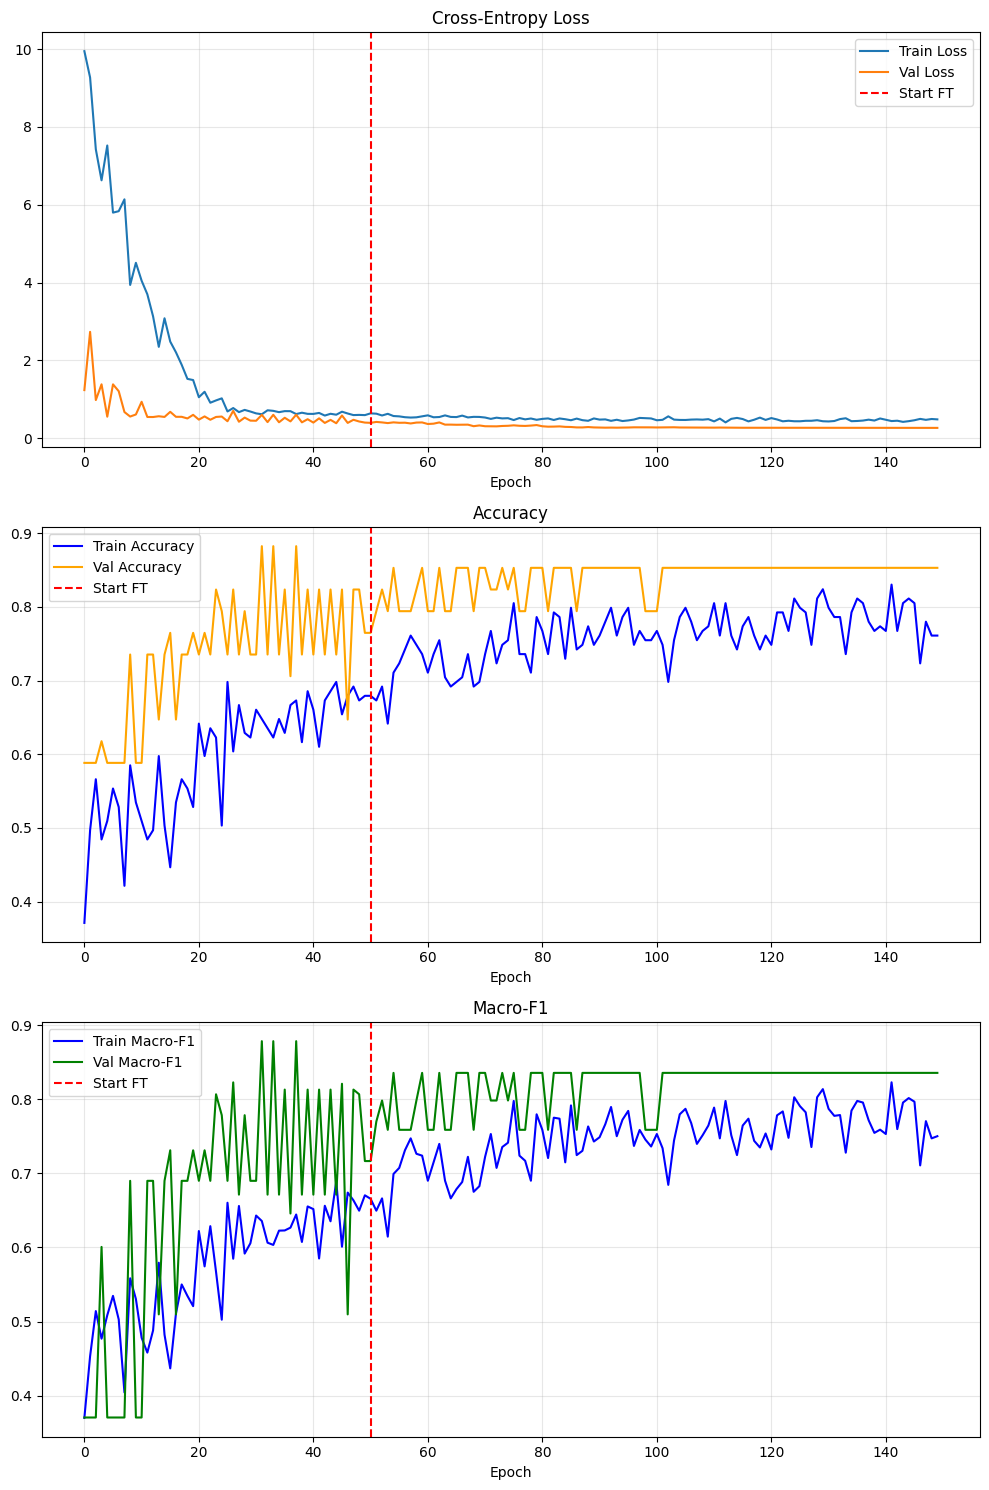

In [89]:
# ============================================================
# CELL 8 — Training Curves
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# --- Loss ---
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[0].set_title("Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Accuracy ---
axes[1].plot(history["train_acc"], label="Train Accuracy", color='blue')
axes[1].plot(history["val_acc"], label="Val Accuracy", color='orange')
axes[1].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- F1 Score ---
axes[2].plot(history["train_f1"], label="Train Macro-F1", color='blue')
axes[2].plot(history["val_f1"], label="Val Macro-F1", color='green')
axes[2].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[2].set_title("Macro-F1")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

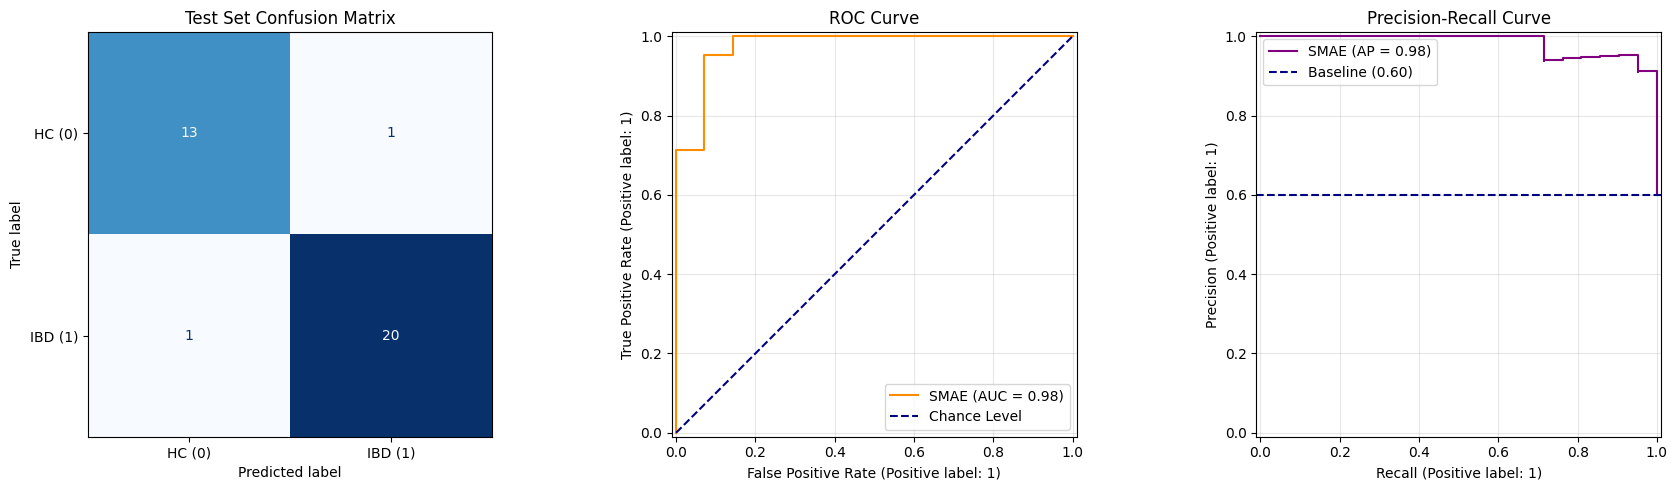


 GLOBAL CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

      HC (0)       0.93      0.93      0.93        14
     IBD (1)       0.95      0.95      0.95        21

    accuracy                           0.94        35
   macro avg       0.94      0.94      0.94        35
weighted avg       0.94      0.94      0.94        35



In [90]:
# ============================================================
# CELL 9 — Clinical Evaluation & Scientific Plotting
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay,
                             PrecisionRecallDisplay)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(labels_test, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HC (0)', 'IBD (1)'])
disp.plot(cmap='Blues', ax=ax1, colorbar=False)
ax1.set_title("Test Set Confusion Matrix")

# 2. ROC Curve
RocCurveDisplay.from_predictions(labels_test, probs_test, ax=ax2, color='darkorange', name='SMAE')
ax2.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Chance Level')
ax2.set_title("ROC Curve")
ax2.grid(alpha=0.3)
ax2.legend()

# 3. PR Curve
PrecisionRecallDisplay.from_predictions(labels_test, probs_test, ax=ax3, color='purple', name='SMAE')
baseline = sum(labels_test) / len(labels_test)
ax3.axhline(baseline, color='navy', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax3.set_title("Precision-Recall Curve")
ax3.grid(alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

print('\n' + '='*50)
print(' GLOBAL CLASSIFICATION REPORT (Test Set)')
print('='*50)
print(classification_report(labels_test, preds_test, target_names=['HC (0)', 'IBD (1)']))


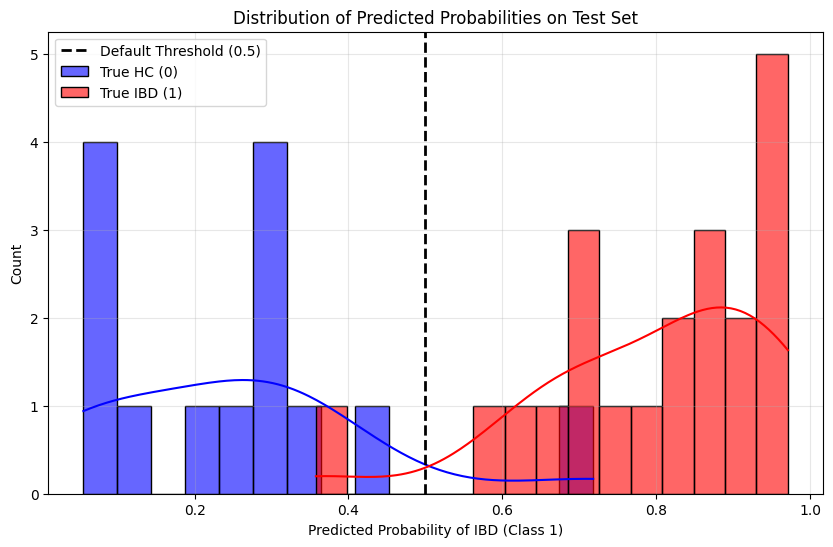

In [91]:
# ============================================================
# CELL 10 — Prediction Distribution (Histogram)
# ============================================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(probs_test[labels_test == 0], bins=15, color='blue', alpha=0.6, label='True HC (0)', kde=True)
sns.histplot(probs_test[labels_test == 1], bins=15, color='red', alpha=0.6, label='True IBD (1)', kde=True)
plt.axvline(0.5, color='k', linestyle='--', linewidth=2, label='Default Threshold (0.5)')
plt.title('Distribution of Predicted Probabilities on Test Set')
plt.xlabel('Predicted Probability of IBD (Class 1)')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [92]:
# ============================================================
# CELL 12 — Caricamento asse X (Raman Shift)
# ============================================================
import numpy as np

# Load the x-axis (Raman shift) from the .npz file
data = np.load(PATH_NPZ)

# Usiamo direttamente la chiave 'wavelengths'
x_axis = data['wavelengths'].flatten()
print("Asse X (Raman Shift) caricato correttamente dalla chiave 'wavelengths'.")
print(f"Range: {x_axis.min():.2f} - {x_axis.max():.2f} cm⁻¹")


Asse X (Raman Shift) caricato correttamente dalla chiave 'wavelengths'.
Range: 650.00 - 1750.00 cm⁻¹


###  K-Fold Evaluation of Test Set Metrics
We train the model 5 times on different folds of the merged training/validation set (85% of the data). At each fold, we calculate the metrics directly on the **isolated Test Set (15%)**. Finally, we calculate the **mean and standard deviation** of the Test Set metrics to evaluate the stability of the model as the training data varies.

In [93]:
# ============================================================
# CELL 13 — K-Fold: Average Test Set Metrics
# ============================================================
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
import copy

# RESTORE THE SEED HERE TO GUARANTEE EXACT REPRODUCIBILITY
# EVEN IF THE CELL IS EXECUTED MULTIPLE TIMES!
set_seed(42)

print("Preparing data for K-Fold...")
# Merge current Train and Val (85% of total data)
X_cv = np.concatenate((X_train, X_val), axis=0)
y_cv = np.concatenate((y_train, y_val), axis=0)

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Lists to save Test Set metrics evaluated in each fold
test_accuracies = []
test_f1s = []
test_aucs = []

# Training parameters IDENTICAL to the single split
K_LP_EPOCHS = 50
K_FT_EPOCHS = 100
K_BATCH_SIZE = 32
PATIENCE = 30

# Prepare the Test Set in tensors immediately
Xte_t = torch.from_numpy(X_test).unsqueeze(1).to(device)
yte_t = y_test

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f"\n--- Starting FOLD {fold+1}/{N_SPLITS} ---")

    X_tr_f, y_tr_f = X_cv[train_idx], y_cv[train_idx]
    X_va_f, y_va_f = X_cv[val_idx], y_cv[val_idx]

    # Conversion to tensors
    Xtr_t = torch.from_numpy(X_tr_f).unsqueeze(1)
    ytr_t = torch.from_numpy(y_tr_f)
    Xva_t = torch.from_numpy(X_va_f).unsqueeze(1)
    yva_t = torch.from_numpy(y_va_f)

    # Datasets
    train_ds = RamanAugmentedDataset(Xtr_t, ytr_t, augment=True)
    val_ds   = RamanAugmentedDataset(Xva_t, yva_t, augment=False)

    loader_tr = DataLoader(train_ds, batch_size=K_BATCH_SIZE, shuffle=True)
    loader_va = DataLoader(val_ds, batch_size=K_BATCH_SIZE, shuffle=False)

    # Initialize Model
    model_f = SMAEClassifier(copy.deepcopy(foundation_model), ENCODER_DIM, n_classes=2).to(device)

    # Balanced weights
    n_s = (y_tr_f == 0).sum()
    n_i = (y_tr_f == 1).sum()
    pesi = [1.0/n_s if n_s>0 else 0, 1.0/n_i if n_i>0 else 0]
    w_t = torch.tensor(pesi, dtype=torch.float32, device=device)
    w_t = w_t / w_t.sum() * 2.0
    criterion_f = torch.nn.CrossEntropyLoss(weight=w_t)

    # ==================================================
    # STAGE 1: Linear Probing
    # ==================================================
    print("  -> STAGE 1: Linear Probing")
    model_f.freeze_encoder()
    opt_lp = AdamW(model_f.head.parameters(), lr=1e-3, betas=(0.9, 0.95))
    sch_lp = ReduceLROnPlateau(opt_lp, mode='min', factor=0.5, patience=8)
    for ep in range(K_LP_EPOCHS):
        model_f.train()
        tot_loss = 0
        for Xb, yb in loader_tr:
            opt_lp.zero_grad()
            loss = criterion_f(model_f(Xb.to(device)), yb.to(device))
            loss.backward()
            opt_lp.step()
            tot_loss += loss.item()

        _, _, _, v_loss = eval_model(model_f, loader_va)
        sch_lp.step(v_loss)

        if (ep + 1) % 10 == 0 or ep == 0:
            print(f"     [LP] Epoch {ep+1:02d}/{K_LP_EPOCHS} | Train Loss: {tot_loss/len(loader_tr):.4f} | Val Loss: {v_loss:.4f}")

    # ==================================================
    # STAGE 2: Fine Tuning
    # ==================================================
    print("  -> STAGE 2: Fine-Tuning")
    model_f.unfreeze_encoder()
    opt_ft = AdamW(model_f.parameters(), lr=1e-5, betas=(0.9, 0.95))
    sch_ft = ReduceLROnPlateau(opt_ft, mode='min', factor=0.5, patience=5)

    best_loss = float('inf')
    best_f1 = 0.0
    best_state = None
    no_imp = 0

    for ep in range(K_FT_EPOCHS):
        model_f.train()
        tot_loss = 0
        for Xb, yb in loader_tr:
            opt_ft.zero_grad()
            loss = criterion_f(model_f(Xb.to(device)), yb.to(device))
            loss.backward()
            opt_ft.step()
            tot_loss += loss.item()

        preds_va, labels_va, _, v_loss = eval_model(model_f, loader_va)
        v_f1 = f1_score(labels_va, preds_va, average="macro")
        sch_ft.step(v_loss)

        if (ep + 1) % 10 == 0 or ep == 0:
            print(f"     [FT] Epoch {ep+1:02d}/{K_FT_EPOCHS} | Train Loss: {tot_loss/len(loader_tr):.4f} | Val Loss: {v_loss:.4f} | Val F1: {v_f1:.4f}")

        # Save based on F1 (like single split)
        if v_f1 > best_f1:
            best_f1 = v_f1
            best_state = {k: v.clone() for k, v in model_f.state_dict().items()}
        elif v_f1 == best_f1 and v_loss < best_loss:
            best_state = {k: v.clone() for k, v in model_f.state_dict().items()}

        if v_loss < best_loss:
            best_loss = v_loss
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= PATIENCE:
                print(f"     [!] Early stopping at epoch {ep+1} (Val Loss not improving)")
                break

    if best_state is not None:
        model_f.load_state_dict(best_state)

    # ==================================================
    # TEST SET EVALUATION FOR CURRENT FOLD
    # ==================================================
    model_f.eval()
    with torch.no_grad():
        logits = model_f(Xte_t)
        probs = torch.nn.functional.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

    acc = accuracy_score(yte_t, preds)
    f1 = f1_score(yte_t, preds, average="macro")
    auc = roc_auc_score(yte_t, probs)

    print(f"  -> Test Set Results (Fold {fold+1}) -> Accuracy: {acc:.4f} | Macro-F1: {f1:.4f} | AUC: {auc:.4f}")

    test_accuracies.append(acc)
    test_f1s.append(f1)
    test_aucs.append(auc)

# ==================================================
# FINAL AVERAGE AND STANDARD DEVIATION
# ==================================================
print("\n" + "="*60)
print(" AVERAGE TEST SET METRICS (5-Fold Cross-Validation) ")
print("="*60)
print(f"Test Accuracy : {np.mean(test_accuracies):.4f} \u00b1 {np.std(test_accuracies):.4f}")
print(f"Test Macro-F1 : {np.mean(test_f1s):.4f} \u00b1 {np.std(test_f1s):.4f}")
print(f"Test ROC-AUC  : {np.mean(test_aucs):.4f} \u00b1 {np.std(test_aucs):.4f}")

Preparing data for K-Fold...

--- Starting FOLD 1/5 ---
  -> STAGE 1: Linear Probing
     [LP] Epoch 01/50 | Train Loss: 29.3673 | Val Loss: 21.0008
     [LP] Epoch 10/50 | Train Loss: 6.1103 | Val Loss: 0.6474
     [LP] Epoch 20/50 | Train Loss: 3.7061 | Val Loss: 0.9469
     [LP] Epoch 30/50 | Train Loss: 0.9878 | Val Loss: 0.5428
     [LP] Epoch 40/50 | Train Loss: 0.5925 | Val Loss: 0.5588
     [LP] Epoch 50/50 | Train Loss: 0.6778 | Val Loss: 0.6569
  -> STAGE 2: Fine-Tuning
     [FT] Epoch 01/100 | Train Loss: 0.6002 | Val Loss: 0.5130 | Val F1: 0.6432
     [FT] Epoch 10/100 | Train Loss: 0.5606 | Val Loss: 0.5112 | Val F1: 0.6631
     [FT] Epoch 20/100 | Train Loss: 0.5402 | Val Loss: 0.5208 | Val F1: 0.6408
     [FT] Epoch 30/100 | Train Loss: 0.6059 | Val Loss: 0.5169 | Val F1: 0.6144
     [FT] Epoch 40/100 | Train Loss: 0.4743 | Val Loss: 0.5106 | Val F1: 0.6389
     [!] Early stopping at epoch 44 (Val Loss not improving)
  -> Test Set Results (Fold 1) -> Accuracy: 0.8286 | M

In [94]:
# ============================================================
# ViT FROM SCRATCH - SIMPLE HOLD-OUT (Train/Val/Test 70-15-15)
# ============================================================
import copy
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

set_seed(42)

# Re-use the existing X_train, X_val, X_test splits from Cell 5
Xtr_t = torch.from_numpy(X_train).unsqueeze(1)
ytr_t = torch.from_numpy(y_train)
Xva_t = torch.from_numpy(X_val).unsqueeze(1)
yva_t = torch.from_numpy(y_val)
Xte_t = torch.from_numpy(X_test).unsqueeze(1).to(device)

# Datasets / DataLoaders
train_ds = RamanAugmentedDataset(Xtr_t, ytr_t, augment=True)
val_ds = RamanAugmentedDataset(Xva_t, yva_t, augment=False)

loader_tr = DataLoader(train_ds, batch_size=32, shuffle=True)
loader_va = DataLoader(val_ds, batch_size=32, shuffle=False)

# Model Init
vit_encoder_scratch_ho = build_smae_encoder()
model_scratch_ho = SMAEClassifier(vit_encoder_scratch_ho, ENCODER_DIM, n_classes=2).to(device)
model_scratch_ho.unfreeze_encoder()

# Loss weights
n_s, n_i = (y_train == 0).sum(), (y_train == 1).sum()
pesi = [1.0 / n_s if n_s > 0 else 0, 1.0 / n_i if n_i > 0 else 0]
w_t = torch.tensor(pesi, dtype=torch.float32, device=device)
w_t = w_t / w_t.sum() * 2.0
criterion_scratch_ho = torch.nn.CrossEntropyLoss(weight=w_t)

print("--- Training ViT from Scratch (Hold-Out) ---")
opt = AdamW(model_scratch_ho.parameters(), lr=1e-4)
sch = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8)

best_state = None
best_f1 = 0.0
best_loss = float('inf')
patience_counter = 0

EPOCHS = 150
for ep in range(EPOCHS):
    model_scratch_ho.train()
    for Xb, yb in loader_tr:
        opt.zero_grad()
        loss = criterion_scratch_ho(model_scratch_ho(Xb.to(device)), yb.to(device))
        loss.backward()
        opt.step()

    preds_va, labels_va, _, v_loss = eval_model(model_scratch_ho, loader_va)
    v_f1 = f1_score(labels_va, preds_va, average='macro')
    sch.step(v_loss)

    if v_f1 > best_f1:
        best_f1 = v_f1
        best_state = {k: v.clone() for k, v in model_scratch_ho.state_dict().items()}
    elif v_f1 == best_f1 and v_loss < best_loss:
        best_state = {k: v.clone() for k, v in model_scratch_ho.state_dict().items()}

    if v_loss < best_loss:
        best_loss = v_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 20:
            print(f"Early stopping @ epoch {ep+1}")
            break

model_scratch_ho.load_state_dict(best_state)
model_scratch_ho.eval()

with torch.no_grad():
    logits = model_scratch_ho(Xte_t)
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds = logits.argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='macro')
auc = roc_auc_score(y_test, probs)

print(f"\n[Test Set Results - Hold-Out Scratch]")
print(f"Accuracy : {acc:.4f}")
print(f"Macro-F1 : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

--- Training ViT from Scratch (Hold-Out) ---
Early stopping @ epoch 23

[Test Set Results - Hold-Out Scratch]
Accuracy : 0.5143
Macro-F1 : 0.4711
ROC-AUC  : 0.7347


In [95]:
# ============================================================
# ViT FROM SCRATCH - STANDARD K-FOLD (Valuta su Test Set fisso)
# ============================================================
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

set_seed(42)

# Use Train+Val for CV, Test is held out
X_cv = np.concatenate((X_train, X_val), axis=0)
y_cv = np.concatenate((y_train, y_val), axis=0)

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

test_accuracies_scratch_kf = []
test_f1s_scratch_kf = []
test_aucs_scratch_kf = []

Xte_t = torch.from_numpy(X_test).unsqueeze(1).to(device)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f"\n--- FOLD {fold+1}/{N_SPLITS} (ViT From Scratch) ---")

    X_tr_f, y_tr_f = X_cv[train_idx], y_cv[train_idx]
    X_va_f, y_va_f = X_cv[val_idx], y_cv[val_idx]

    Xtr_t = torch.from_numpy(X_tr_f).unsqueeze(1)
    ytr_t = torch.from_numpy(y_tr_f)
    Xva_t = torch.from_numpy(X_va_f).unsqueeze(1)
    yva_t = torch.from_numpy(y_va_f)

    train_ds = RamanAugmentedDataset(Xtr_t, ytr_t, augment=True)
    val_ds   = RamanAugmentedDataset(Xva_t, yva_t, augment=False)

    loader_tr = DataLoader(train_ds, batch_size=32, shuffle=True)
    loader_va = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Init from scratch
    vit_encoder_scratch_kf = build_smae_encoder()
    model_scratch_kf = SMAEClassifier(vit_encoder_scratch_kf, ENCODER_DIM, n_classes=2).to(device)
    model_scratch_kf.unfreeze_encoder()

    n_s, n_i = (y_tr_f == 0).sum(), (y_tr_f == 1).sum()
    pesi = [1.0/n_s if n_s>0 else 0, 1.0/n_i if n_i>0 else 0]
    w_t = torch.tensor(pesi, dtype=torch.float32, device=device)
    w_t = w_t / w_t.sum() * 2.0
    criterion_scratch_kf = torch.nn.CrossEntropyLoss(weight=w_t)

    opt = AdamW(model_scratch_kf.parameters(), lr=1e-4)
    sch = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8)

    best_state = None
    best_f1 = 0.0
    best_loss = float('inf')
    no_imp = 0

    for ep in range(150):
        model_scratch_kf.train()
        for Xb, yb in loader_tr:
            opt.zero_grad()
            loss = criterion_scratch_kf(model_scratch_kf(Xb.to(device)), yb.to(device))
            loss.backward()
            opt.step()

        preds_va, labels_va, _, v_loss = eval_model(model_scratch_kf, loader_va)
        v_f1 = f1_score(labels_va, preds_va, average="macro")
        sch.step(v_loss)

        if v_f1 > best_f1:
            best_f1 = v_f1
            best_state = {k: v.clone() for k, v in model_scratch_kf.state_dict().items()}
        elif v_f1 == best_f1 and v_loss < best_loss:
            best_state = {k: v.clone() for k, v in model_scratch_kf.state_dict().items()}

        if v_loss < best_loss:
            best_loss = v_loss
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= 20:
                print(f"     Early stopping at epoch {ep+1}")
                break

    model_scratch_kf.load_state_dict(best_state)
    model_scratch_kf.eval()
    with torch.no_grad():
        logits = model_scratch_kf(Xte_t)
        probs = torch.nn.functional.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    auc = roc_auc_score(y_test, probs)

    print(f"  -> Test Set (Fold {fold+1}) -> Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

    test_accuracies_scratch_kf.append(acc)
    test_f1s_scratch_kf.append(f1)
    test_aucs_scratch_kf.append(auc)

print("\n" + "="*60)
print(" METRICHE MEDIE TEST SET - K-FOLD (ViT Da Zero) ")
print("="*60)
print(f"Test Accuracy : {np.mean(test_accuracies_scratch_kf):.4f} ± {np.std(test_accuracies_scratch_kf):.4f}")
print(f"Test Macro-F1 : {np.mean(test_f1s_scratch_kf):.4f} ± {np.std(test_f1s_scratch_kf):.4f}")
print(f"Test ROC-AUC  : {np.mean(test_aucs_scratch_kf):.4f} ± {np.std(test_aucs_scratch_kf):.4f}")


--- FOLD 1/5 (ViT From Scratch) ---
     Early stopping at epoch 44
  -> Test Set (Fold 1) -> Acc: 0.6857 | F1: 0.6847 | AUC: 0.7721

--- FOLD 2/5 (ViT From Scratch) ---
     Early stopping at epoch 35
  -> Test Set (Fold 2) -> Acc: 0.6857 | F1: 0.5727 | AUC: 0.8605

--- FOLD 3/5 (ViT From Scratch) ---
     Early stopping at epoch 25
  -> Test Set (Fold 3) -> Acc: 0.5429 | F1: 0.4400 | AUC: 0.7517

--- FOLD 4/5 (ViT From Scratch) ---
     Early stopping at epoch 36
  -> Test Set (Fold 4) -> Acc: 0.7714 | F1: 0.7712 | AUC: 0.8844

--- FOLD 5/5 (ViT From Scratch) ---
     Early stopping at epoch 22
  -> Test Set (Fold 5) -> Acc: 0.5143 | F1: 0.4711 | AUC: 0.7449

 METRICHE MEDIE TEST SET - K-FOLD (ViT Da Zero) 
Test Accuracy : 0.6400 ± 0.0966
Test Macro-F1 : 0.5879 ± 0.1255
Test ROC-AUC  : 0.8027 ± 0.0581


In [96]:
import numpy as np
from scipy.signal import find_peaks

# Number of main peaks to show
TOP_N = 5

def get_top_peaks(saliency_array, x_axis, top_n=5, distance=10):
    # Find local peaks (distance avoids taking points that are too close)
    peaks, properties = find_peaks(saliency_array, distance=distance)

    # Sort peaks based on height (saliency) in descending order
    peak_heights = saliency_array[peaks]
    sorted_indices = np.argsort(peak_heights)[::-1]

    top_peaks_indices = peaks[sorted_indices][:top_n]

    results = []
    for idx in top_peaks_indices:
        results.append({
            'raman_shift': x_axis[idx],
            'importance': saliency_array[idx],
            'index': idx # Added for future convenience
        })
    return results

print("get_top_peaks function defined correctly.")

get_top_peaks function defined correctly.


In [97]:
# ============================================================
# CELL 14 — Top Biomarkers Formatting
# ============================================================
import pandas as pd

def format_top_peaks(peaks):
    formatted_results = []
    for p in peaks:
        formatted_results.append({
            'Model Raman Shift (cm⁻¹)': f"{p['raman_shift']:.2f}",
            'Importance': f"{p['importance']:.3f}",
        })
    return pd.DataFrame(formatted_results)

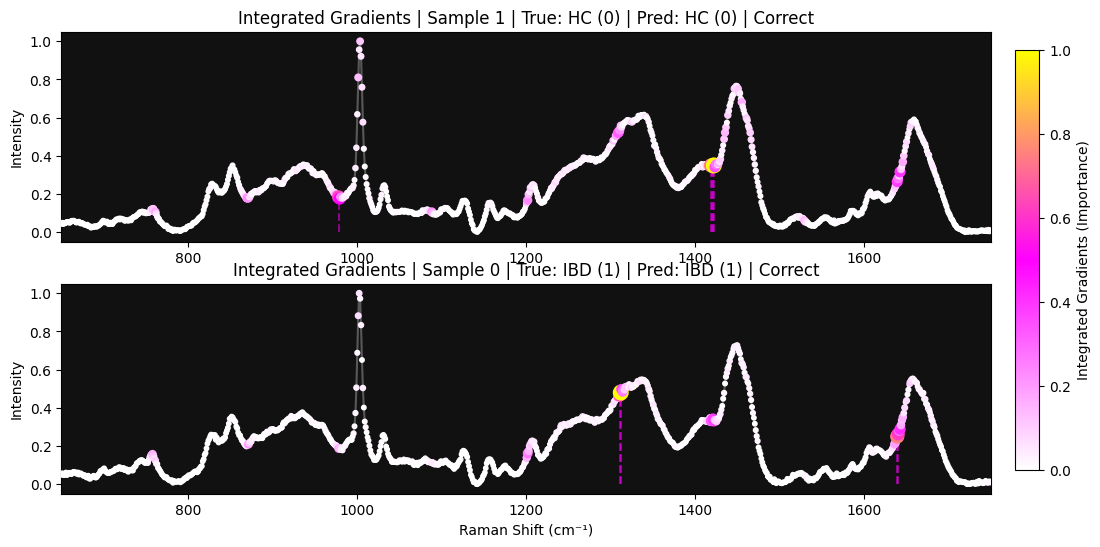

In [98]:
# ============================================================
# CELL 15 — Advanced Interpretability: Integrated Gradients
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def integrated_gradients(model, input_tensor, baseline=None, target_class_idx=None, steps=50):
    """Calculates Integrated Gradients for a single sample."""
    if baseline is None:
        # Baseline of zeros of the same shape as the input
        baseline = torch.zeros_like(input_tensor)

    # Create the various steps (linear interpolation between baseline and input)
    scaled_inputs = [baseline + (float(i) / steps) * (input_tensor - baseline) for i in range(0, steps + 1)]

    grads = []
    for scaled_input in scaled_inputs:
        scaled_input.requires_grad_()
        logits = model(scaled_input)

        if target_class_idx is None:
            target_class_idx = logits.argmax(dim=1).item()

        score = logits[0, target_class_idx]
        model.zero_grad()
        score.backward()

        grads.append(scaled_input.grad.detach())

    # Average the gradients calculated along the path
    avg_grads = torch.stack(grads[:-1]).mean(dim=0)

    # Multiply by the difference (input - baseline)
    integrated_grad = (input_tensor - baseline).detach() * avg_grads

    return integrated_grad.squeeze().cpu().numpy()

# Find CORRECTLY predicted samples for visualization
model.eval()
with torch.no_grad():
    logits_all = model(Xte.to(device))
    preds_all = logits_all.argmax(dim=1).cpu().numpy()
labels_all = yte.numpy()

# Find the first correct HC and the first correct IBD with a fallback in case of absence
hc_indices = np.where((labels_all == 0) & (preds_all == 0))[0]
if len(hc_indices) > 0:
    correct_hc_idx = hc_indices[0]
else:
    print("No correctly predicted HC sample. Selecting the first HC sample.")
    correct_hc_idx = np.where(labels_all == 0)[0][0]

ibd_indices = np.where((labels_all == 1) & (preds_all == 1))[0]
if len(ibd_indices) > 0:
    correct_ibd_idx = ibd_indices[0]
else:
    print("No correctly predicted IBD sample. Selecting the first IBD sample.")
    correct_ibd_idx = np.where(labels_all == 1)[0][0]

selected_indices = [correct_hc_idx, correct_ibd_idx]

X_vis = Xte[selected_indices].to(device)
y_vis = yte[selected_indices].to(device)
num_samples = len(selected_indices)

fig, axes = plt.subplots(num_samples, 1, figsize=(12, 3 * num_samples))
if num_samples == 1: axes = [axes]

# Custom Colormap: White (0) -> Magenta -> Yellow (High)
cmap_ig = mcolors.LinearSegmentedColormap.from_list("white_magenta", ["white", "magenta", "yellow"])

for i in range(num_samples):
    input_sample = X_vis[i:i+1] # Keep batch dimension
    true_label = y_vis[i].item()

    # Forward to calculate Integrated Gradients on the REAL class (which coincides with the predicted if correct)
    pred_class = true_label

    ig = integrated_gradients(model, input_sample, target_class_idx=pred_class, steps=50)
    spectrum = input_sample.squeeze().cpu().numpy()

    # Normalize the absolute value of IG for visualization
    ig_abs = np.abs(ig)
    ig_norm = (ig_abs - ig_abs.min()) / (ig_abs.max() - ig_abs.min() + 1e-8)

    ax = axes[i]
    ax.set_facecolor('#111111') # Sfondo scuro per massimo contrasto
    ax.plot(x_axis, spectrum, color='white', alpha=0.3, label='Raman Spectrum')

    # Add drop lines for most important features
    top_idx = np.where(ig_norm > 0.5)[0]
    ax.vlines(x_axis[top_idx], ymin=spectrum.min(), ymax=spectrum[top_idx], color='magenta', alpha=0.5, linestyle='--', zorder=3)

    # Custom color map on dark background
    scatter = ax.scatter(x_axis, spectrum, c=ig_norm, cmap=cmap_ig, s=ig_norm*100 + 10, zorder=5)

    true_str = "HC (0)" if true_label == 0 else "IBD (1)"
    pred_str = "HC (0)" if preds_all[selected_indices[i]] == 0 else "IBD (1)"
    status_str = "Correct" if true_label == preds_all[selected_indices[i]] else "INCORRECT"

    ax.set_title(f"Integrated Gradients | Sample {selected_indices[i]} | True: {true_str} | Pred: {pred_str} | {status_str}")
    ax.set_xlim(x_axis.min(), x_axis.max())
    ax.set_ylabel("Intensity")
    if i == num_samples - 1:
        ax.set_xlabel("Raman Shift (cm⁻¹)")

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(scatter, cax=cbar_ax, label='Integrated Gradients (Importance)')

plt.subplots_adjust(right=0.9)
plt.show()


Calculating Integrated Gradients for the entire Test Set. This may take a few seconds...


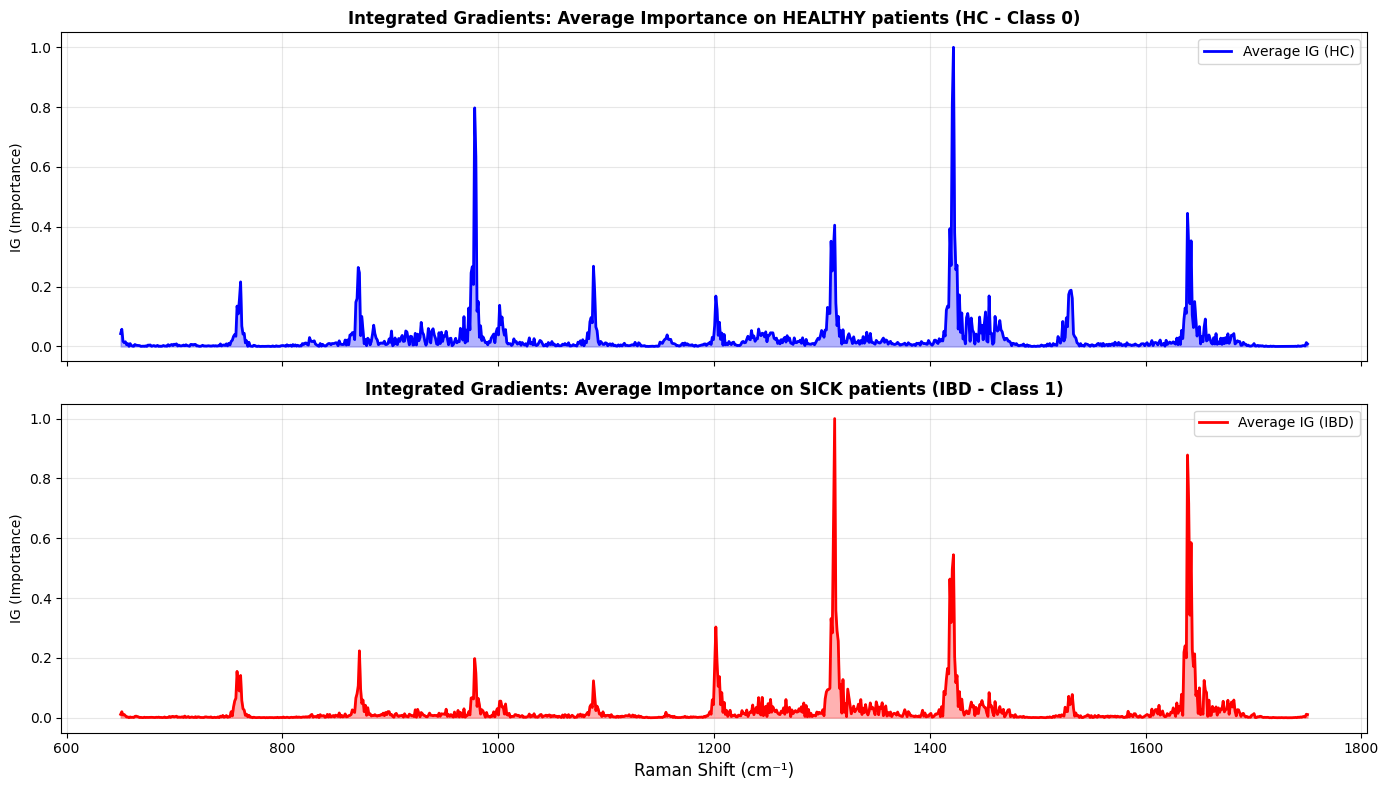

In [99]:
# ============================================================
# CELL 16 — Global Integrated Gradients: Average per Class
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()
ig_all = []

print("Calculating Integrated Gradients for the entire Test Set. This may take a few seconds...")

# We use the complete test set (Xte, yte)
for i in range(len(Xte)):
    input_sample = Xte[i:i+1].to(device)

    # Prediction to find the target class
    logits = model(input_sample)
    pred_class = logits.argmax(dim=1).item()

    # Calculate IG for the predicted class
    ig = integrated_gradients(model, input_sample, target_class_idx=pred_class, steps=50)

    # Save the absolute value of the importance
    ig_all.append(np.abs(ig))

ig_all = np.array(ig_all)

# Divide the importances based on the REAL labels of the test set
ig_hc_mean = ig_all[y_test == 0].mean(axis=0)
ig_ibd_mean = ig_all[y_test == 1].mean(axis=0)

# Normalization between 0 and 1 for better visualization
ig_hc_mean = (ig_hc_mean - ig_hc_mean.min()) / (ig_hc_mean.max() - ig_hc_mean.min() + 1e-8)
ig_ibd_mean = (ig_ibd_mean - ig_ibd_mean.min()) / (ig_ibd_mean.max() - ig_ibd_mean.min() + 1e-8)

# Creation of the global plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 1. Average IG profile for HC
axes[0].plot(x_axis, ig_hc_mean, color='blue', linewidth=2, label='Average IG (HC)')
axes[0].fill_between(x_axis, 0, ig_hc_mean, color='blue', alpha=0.3)
axes[0].set_title("Integrated Gradients: Average Importance on HEALTHY patients (HC - Class 0)", fontweight='bold')
axes[0].set_ylabel("IG (Importance)")
axes[0].grid(alpha=0.3)
axes[0].legend()

# 2. Average IG profile for IBD
axes[1].plot(x_axis, ig_ibd_mean, color='red', linewidth=2, label='Average IG (IBD)')
axes[1].fill_between(x_axis, 0, ig_ibd_mean, color='red', alpha=0.3)
axes[1].set_title("Integrated Gradients: Average Importance on SICK patients (IBD - Class 1)", fontweight='bold')
axes[1].set_xlabel("Raman Shift (cm⁻¹)", fontsize=12)
axes[1].set_ylabel("IG (Importance)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [100]:
# ============================================================
# CELL 17 — Biomarker Comparison with Integrated Gradients
# ============================================================
print("="*50)
print(" BIOMARKER COMPARISON (INTEGRATED GRADIENTS)")
print("="*50)

# Extract the top N peaks using the previously defined function
peaks_hc_ig = get_top_peaks(ig_hc_mean, x_axis, TOP_N)
peaks_ibd_ig = get_top_peaks(ig_ibd_mean, x_axis, TOP_N)

print("\n--- Top HEALTHY Peaks (HC) with IG --- ")
df_hc_ig = format_top_peaks(peaks_hc_ig)
display(df_hc_ig)

print("\n--- Top SICK Peaks (IBD) with IG --- ")
df_ibd_ig = format_top_peaks(peaks_ibd_ig)
display(df_ibd_ig)

 BIOMARKER COMPARISON (INTEGRATED GRADIENTS)

--- Top HEALTHY Peaks (HC) with IG --- 


,Model Raman Shift (cm⁻¹),Importance
0,1421.87,1.000
1,978.13,0.797
2,1638.79,0.445
3,1311.76,0.405
4,1088.24,0.268



--- Top SICK Peaks (IBD) with IG --- 


,Model Raman Shift (cm⁻¹),Importance
0,1311.76,1.000
1,1638.79,0.878
2,1421.87,0.545
3,1201.65,0.303
4,871.32,0.224


Calculating SHAP values (may take a few seconds/minutes)...


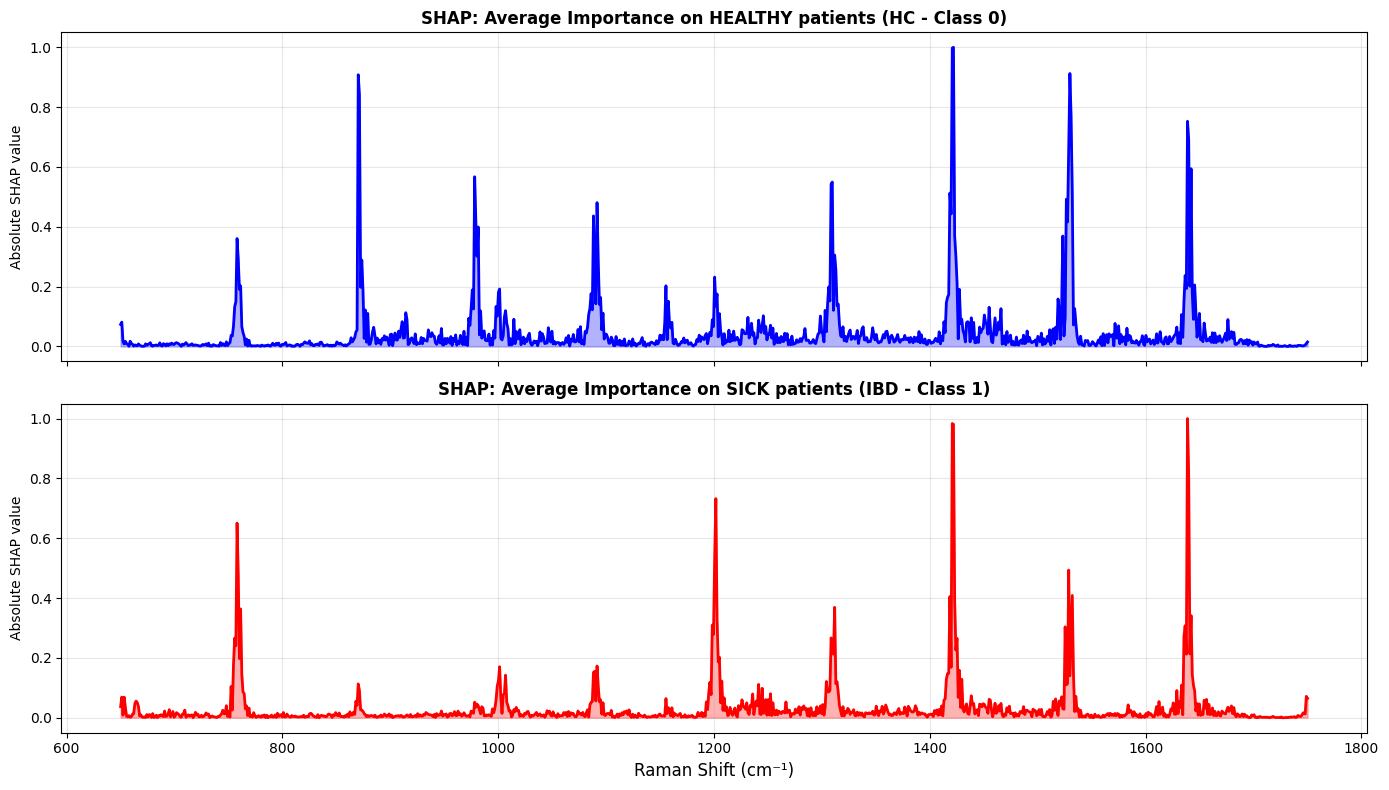

In [101]:
# ============================================================
# CELL 18 — SHAP (SHapley Additive exPlanations)
# ============================================================
import shap
import numpy as np
import matplotlib.pyplot as plt
import torch

model.eval()

# SHAP needs a background dataset to calculate expected values
# For maximum reliability, we take 100 random samples from the TRAINING SET (Xtr)
np.random.seed(42)
background_indices = np.random.choice(len(Xtr), 100, replace=False)
background = Xtr[background_indices].to(device)
test_samples = Xte.to(device)

print("Calculating SHAP values (may take a few seconds/minutes)...")
# GradientExplainer is fast and stable for differentiable PyTorch models
explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_samples)

# Dynamic shape handling based on SHAP version
if isinstance(shap_values, list):
    # If it's a list, the index is the class [Class, Batch, Channels, Seq]
    shap_hc = np.abs(shap_values[0]).reshape(len(test_samples), -1)
    shap_ibd = np.abs(shap_values[1]).reshape(len(test_samples), -1)
else:
    # If it's an array, the index is [Batch, Class, ...] or [Batch, Channels, Seq, Class]
    # We transform into (N_test, N_classes, 500)
    shap_values = np.array(shap_values)
    if shap_values.shape[1] == 2:  # Shape: (Batch, Class, Channels, Seq)
        shap_hc = np.abs(shap_values[:, 0]).reshape(len(test_samples), -1)
        shap_ibd = np.abs(shap_values[:, 1]).reshape(len(test_samples), -1)
    elif shap_values.shape[-1] == 2: # Shape: (Batch, Channels, Seq, Class)
        shap_hc = np.abs(shap_values[..., 0]).reshape(len(test_samples), -1)
        shap_ibd = np.abs(shap_values[..., 1]).reshape(len(test_samples), -1)
    else:
        raise ValueError(f"Unrecognized SHAP format: {shap_values.shape}")

# Calculate average importance per class
shap_hc_mean = shap_hc[y_test == 0].mean(axis=0)
shap_ibd_mean = shap_ibd[y_test == 1].mean(axis=0)

# Normalization between 0 and 1 for visualization
shap_hc_mean = (shap_hc_mean - shap_hc_mean.min()) / (shap_hc_mean.max() - shap_hc_mean.min() + 1e-8)
shap_ibd_mean = (shap_ibd_mean - shap_ibd_mean.min()) / (shap_ibd_mean.max() - shap_ibd_mean.min() + 1e-8)

# --- PLOT SHAP ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(x_axis, shap_hc_mean, color='blue', linewidth=2)
axes[0].fill_between(x_axis, 0, shap_hc_mean, color='blue', alpha=0.3)
axes[0].set_title("SHAP: Average Importance on HEALTHY patients (HC - Class 0)", fontweight='bold')
axes[0].set_ylabel("Absolute SHAP value")
axes[0].grid(alpha=0.3)

axes[1].plot(x_axis, shap_ibd_mean, color='red', linewidth=2)
axes[1].fill_between(x_axis, 0, shap_ibd_mean, color='red', alpha=0.3)
axes[1].set_title("SHAP: Average Importance on SICK patients (IBD - Class 1)", fontweight='bold')
axes[1].set_xlabel("Raman Shift (cm⁻¹)", fontsize=12)
axes[1].set_ylabel("Absolute SHAP value")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [102]:
# ============================================================
# CELL 19 — Biomarker Comparison with SHAP
# ============================================================
print("="*50)
print(" BIOMARKER COMPARISON (SHAP)")
print("="*50)

peaks_hc_shap = get_top_peaks(shap_hc_mean, x_axis, TOP_N)
peaks_ibd_shap = get_top_peaks(shap_ibd_mean, x_axis, TOP_N)

print("\n--- Top HEALTHY Peaks (HC) with SHAP --- ")
df_hc_shap = format_top_peaks(peaks_hc_shap)
display(df_hc_shap)

print("\n--- Top SICK Peaks (IBD) with SHAP --- ")
df_ibd_shap = format_top_peaks(peaks_ibd_shap)
display(df_ibd_shap)

 BIOMARKER COMPARISON (SHAP)

--- Top HEALTHY Peaks (HC) with SHAP --- 


,Model Raman Shift (cm⁻¹),Importance
0,1421.87,1.000
1,1529.78,0.912
2,870.22,0.908
3,1638.79,0.753
4,978.13,0.567



--- Top SICK Peaks (IBD) with SHAP --- 


,Model Raman Shift (cm⁻¹),Importance
0,1638.79,1.000
1,1420.77,0.983
2,1201.65,0.732
3,757.91,0.651
4,1528.68,0.494


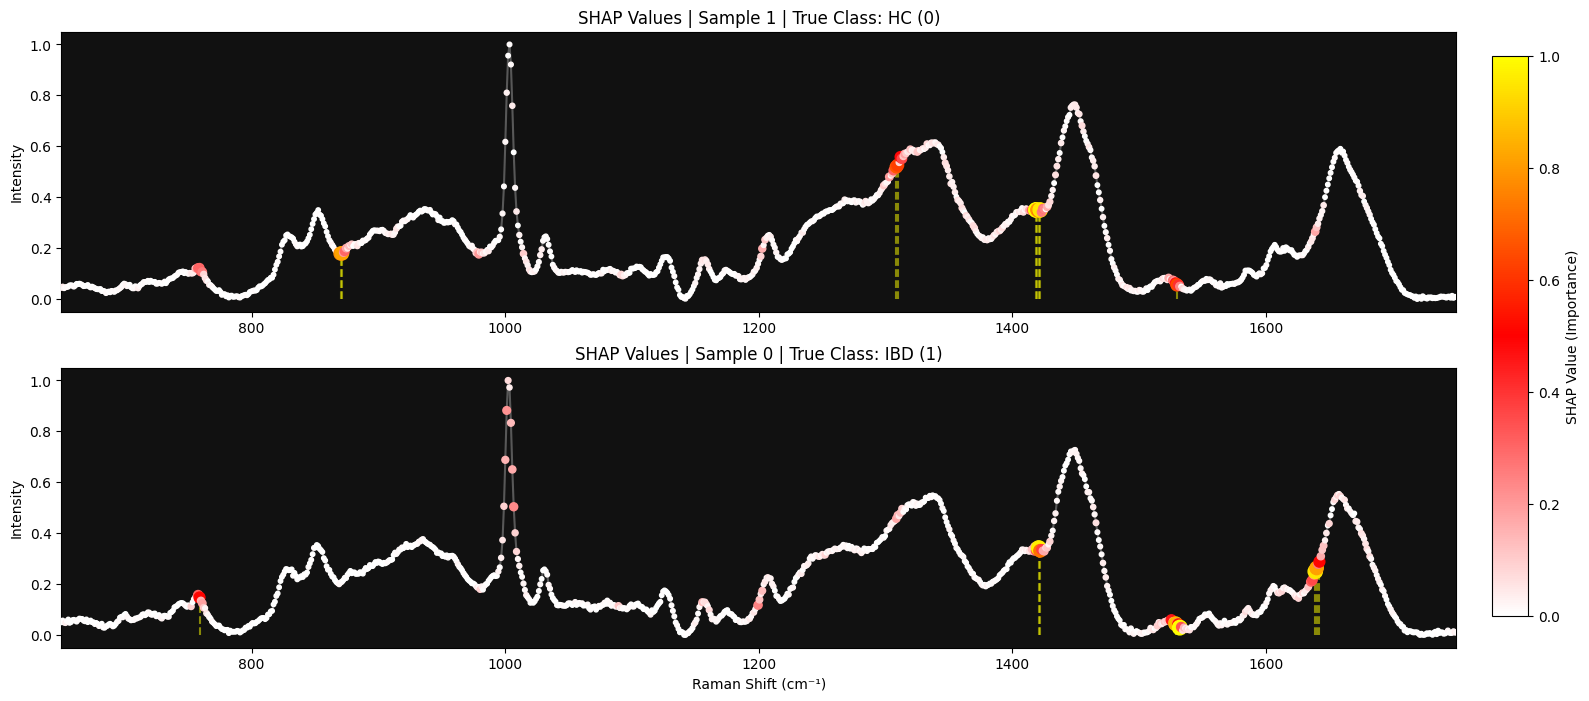

In [103]:
# ============================================================
# CELL 19b — SHAP on Single Sample (IG / Saliency Style)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

num_samples = len(selected_indices)
fig, axes = plt.subplots(num_samples, 1, figsize=(18, 4 * num_samples))
if num_samples == 1: axes = [axes]

# Custom Colormap: White (0) -> Red -> Yellow (High)
cmap_shap = mcolors.LinearSegmentedColormap.from_list("white_red", ["white", "red", "yellow"])

for i in range(num_samples):
    idx = selected_indices[i]
    true_label = labels_all[idx]

    spectrum = Xte[idx].squeeze().cpu().numpy()
    shap_val = shap_hc[idx] if true_label == 0 else shap_ibd[idx]
    shap_norm = (shap_val - shap_val.min()) / (shap_val.max() - shap_val.min() + 1e-8)

    ax = axes[i]
    ax.set_facecolor('#111111') # Sfondo scuro per massimo contrasto
    ax.plot(x_axis, spectrum, color='white', alpha=0.3, label='Raman Spectrum')

    top_idx = np.where(shap_norm > 0.5)[0]
    # Plot drop lines ONLY for top features
    ax.vlines(x_axis[top_idx], ymin=spectrum.min(), ymax=spectrum[top_idx], color='yellow', alpha=0.5, linestyle='--', zorder=3)

    # Scatter style with proportional size and custom map (white at 0)
    ax.scatter(x_axis, spectrum, c=shap_norm, cmap=cmap_shap, s=shap_norm*100 + 10, zorder=5)

    true_str = "HC (0)" if true_label == 0 else "IBD (1)"
    ax.set_title(f"SHAP Values | Sample {idx} | True Class: {true_str}")
    ax.set_xlim(x_axis.min(), x_axis.max())
    ax.set_ylabel("Intensity")

    if i == num_samples - 1:
        ax.set_xlabel("Raman Shift (cm⁻¹)")

sm = plt.cm.ScalarMappable(cmap=cmap_shap, norm=plt.Normalize(vmin=0, vmax=1))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(sm, cax=cbar_ax, label='SHAP Value (Importance)')

plt.subplots_adjust(right=0.9)
plt.show()


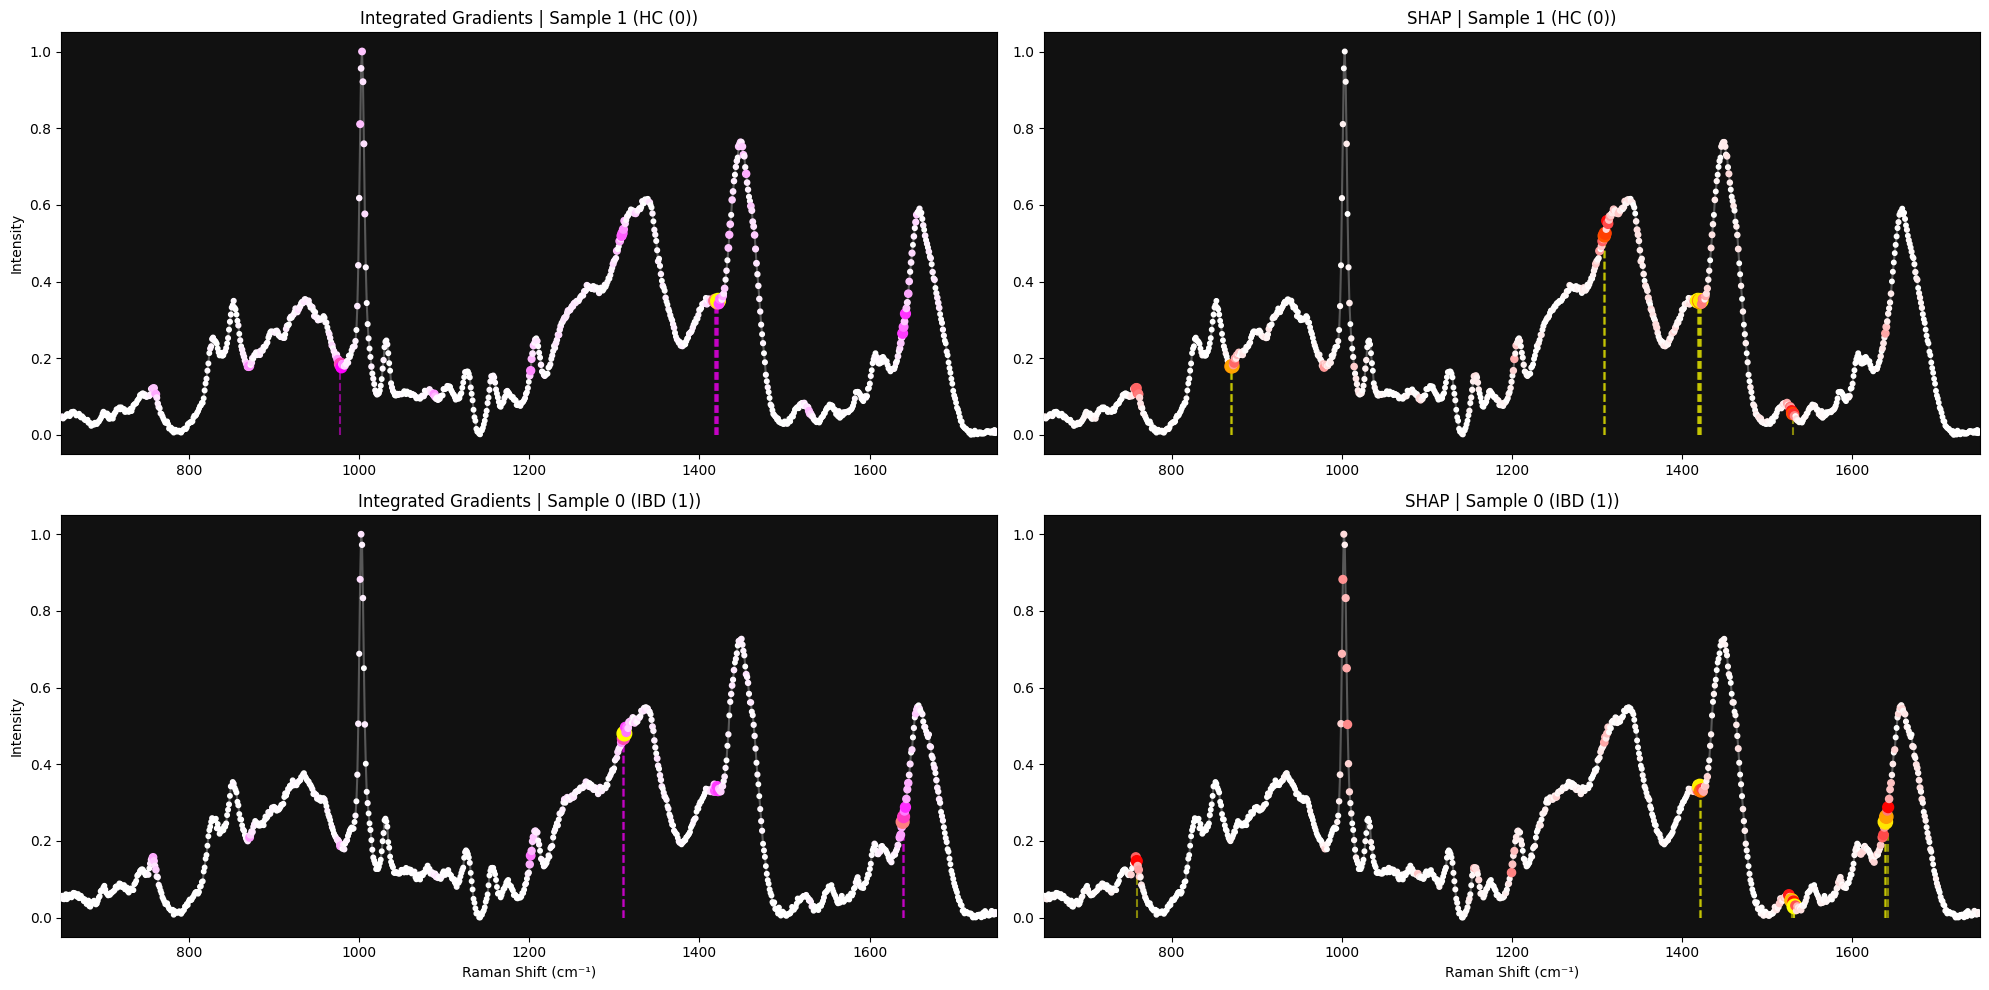

In [104]:
# ============================================================
# CELL 20 — Direct Comparison of IG and SHAP on the same samples
# ============================================================
import matplotlib.pyplot as plt
import torch
import numpy as np
import matplotlib.colors as mcolors

num_samples = len(selected_indices)
fig, axes = plt.subplots(num_samples, 2, figsize=(20, 5 * num_samples))
if num_samples == 1: axes = [axes]

# Custom Colormaps where 0 is White
cmap_ig = mcolors.LinearSegmentedColormap.from_list("white_magenta", ["white", "magenta", "yellow"])
cmap_shap = mcolors.LinearSegmentedColormap.from_list("white_red", ["white", "red", "yellow"])

model.eval()

for i, idx in enumerate(selected_indices):
    input_sample = Xte[idx:idx+1].to(device)
    true_label = labels_all[idx]
    true_str = "HC (0)" if true_label == 0 else "IBD (1)"
    spectrum = input_sample.squeeze().cpu().detach().numpy()

    logits = model(input_sample)
    pred_class = logits.argmax(dim=1).item()

    # 1. INTEGRATED GRADIENTS
    ig = integrated_gradients(model, input_sample.detach(), target_class_idx=pred_class, steps=50)
    ig_abs = np.abs(ig)
    ig_norm = (ig_abs - ig_abs.min()) / (ig_abs.max() - ig_abs.min() + 1e-8)

    # 2. SHAP
    shap_val = shap_hc[idx] if true_label == 0 else shap_ibd[idx]
    shap_norm = (shap_val - shap_val.min()) / (shap_val.max() - shap_val.min() + 1e-8)

    # ================= PLOTTING =================

    # Column 1: IG
    ax = axes[i, 0]
    ax.set_facecolor('#111111')
    ax.plot(x_axis, spectrum, color='white', alpha=0.3)

    ig_top_idx = np.where(ig_norm > 0.5)[0]
    ax.vlines(x_axis[ig_top_idx], ymin=spectrum.min(), ymax=spectrum[ig_top_idx], color='magenta', alpha=0.5, linestyle='--', zorder=3)
    ax.scatter(x_axis, spectrum, c=ig_norm, cmap=cmap_ig, s=ig_norm*100 + 10, zorder=5)

    ax.set_title(f"Integrated Gradients | Sample {idx} ({true_str})")
    ax.set_xlim(x_axis.min(), x_axis.max())
    ax.set_ylabel("Intensity")

    # Column 2: SHAP
    ax = axes[i, 1]
    ax.set_facecolor('#111111')
    ax.plot(x_axis, spectrum, color='white', alpha=0.3)

    shap_top_idx = np.where(shap_norm > 0.5)[0]
    ax.vlines(x_axis[shap_top_idx], ymin=spectrum.min(), ymax=spectrum[shap_top_idx], color='yellow', alpha=0.5, linestyle='--', zorder=3)
    ax.scatter(x_axis, spectrum, c=shap_norm, cmap=cmap_shap, s=shap_norm*100 + 10, zorder=5)

    ax.set_title(f"SHAP | Sample {idx} ({true_str})")
    ax.set_xlim(x_axis.min(), x_axis.max())

    if i == num_samples - 1:
        axes[i, 0].set_xlabel("Raman Shift (cm⁻¹)")
        axes[i, 1].set_xlabel("Raman Shift (cm⁻¹)")

plt.tight_layout()
plt.show()


Preparing SHAP Summary Plot...


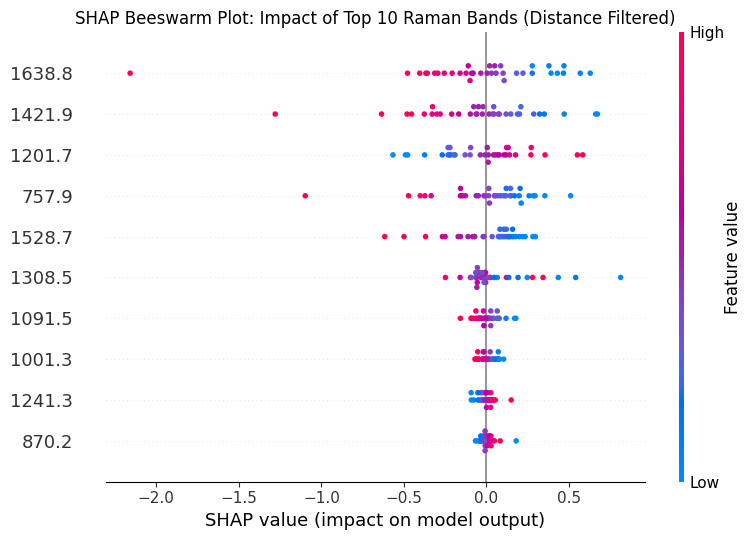

In [105]:
# ============================================================
# CELL 21 — SHAP Summary Plot (Beeswarm) on Top Features
# ============================================================
import shap
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

print("Preparing SHAP Summary Plot...")

if isinstance(shap_values, list):
    shap_vals_ibd_raw = shap_values[1].reshape(len(Xte), -1)
else:
    if shap_values.shape[1] == 2:
        shap_vals_ibd_raw = shap_values[:, 1].reshape(len(Xte), -1)
    else:
        shap_vals_ibd_raw = shap_values[..., 1].reshape(len(Xte), -1)

mean_abs_shap = np.mean(np.abs(shap_vals_ibd_raw), axis=0)

# Filter peaks to prevent adjacent features from taking all top N
TOP_N_SHAP = 10
peaks, _ = find_peaks(mean_abs_shap, distance=10)
peak_heights = mean_abs_shap[peaks]
sorted_peak_indices = np.argsort(peak_heights)[::-1]
top_indices = peaks[sorted_peak_indices][:TOP_N_SHAP]

# Filter SHAP values and data (Test Set) only for these Top N features
shap_vals_top = shap_vals_ibd_raw[:, top_indices]
Xte_flat = Xte.squeeze().cpu().numpy()
Xte_top = Xte_flat[:, top_indices]

# Create understandable feature names: "Wavenumber (cm⁻¹)"
feature_names = [f"{x_axis[i]:.1f}" for i in top_indices]

explanation = shap.Explanation(
    values=shap_vals_top,
    data=Xte_top,
    feature_names=feature_names
)

plt.figure(figsize=(12, 6))
shap.plots.beeswarm(explanation, max_display=TOP_N_SHAP, show=False)
plt.title("SHAP Beeswarm Plot: Impact of Top 10 Raman Bands (Distance Filtered)")
plt.tight_layout()
plt.show()

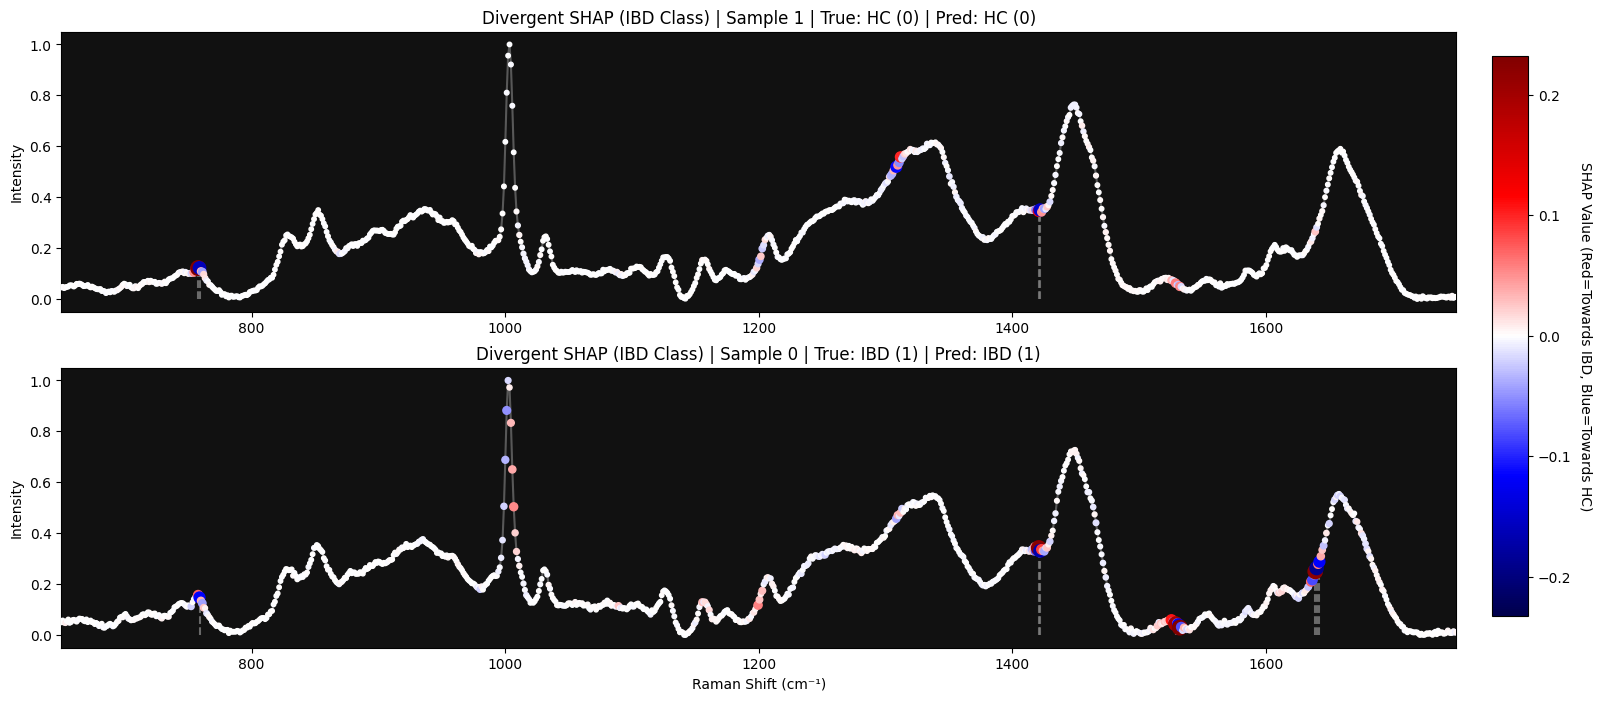

In [106]:
# ============================================================
# CELL 20b — SHAP with Divergent Colormap (Single Spectrum)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.cm as cm

num_samples = len(selected_indices)
fig, axes = plt.subplots(num_samples, 1, figsize=(18, 4 * num_samples))
if num_samples == 1: axes = [axes]

for i in range(num_samples):
    idx = selected_indices[i]
    true_label = labels_all[idx]
    spectrum = Xte[idx].squeeze().cpu().numpy()

    if isinstance(shap_values, list):
        raw_shap = shap_values[1][idx].reshape(-1)
    else:
        if shap_values.shape[1] == 2:
            raw_shap = shap_values[idx, 1].reshape(-1)
        else:
            raw_shap = shap_values[idx, ..., 1].reshape(-1)

    max_abs = np.max(np.abs(raw_shap)) + 1e-8
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0., vmax=max_abs)
    importance_norm = np.abs(raw_shap) / max_abs

    ax = axes[i]
    ax.set_facecolor('#111111') # Dark theme for vibrant contrast
    ax.plot(x_axis, spectrum, color='white', alpha=0.3, label='Raman Spectrum')

    top_idx = np.where(importance_norm > 0.5)[0]
    ax.vlines(x_axis[top_idx], ymin=spectrum.min(), ymax=spectrum[top_idx], color='gray', alpha=0.8, linestyle='--', zorder=3)

    # Divergent scatter with high-contrast seismic map
    ax.scatter(x_axis, spectrum, c=raw_shap, cmap='seismic', norm=norm, s=importance_norm*100 + 10, zorder=5)

    true_str = "HC (0)" if true_label == 0 else "IBD (1)"
    pred_str = "HC (0)" if preds_all[idx] == 0 else "IBD (1)"
    ax.set_title(f"Divergent SHAP (IBD Class) | Sample {idx} | True: {true_str} | Pred: {pred_str}")
    ax.set_xlim(x_axis.min(), x_axis.max())
    ax.set_ylabel("Intensity")

    if i == num_samples - 1:
        ax.set_xlabel("Raman Shift (cm⁻¹)")

sm = plt.cm.ScalarMappable(cmap='seismic', norm=norm)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('SHAP Value (Red=Towards IBD, Blue=Towards HC)', rotation=270, labelpad=15)

plt.subplots_adjust(right=0.9)
plt.show()


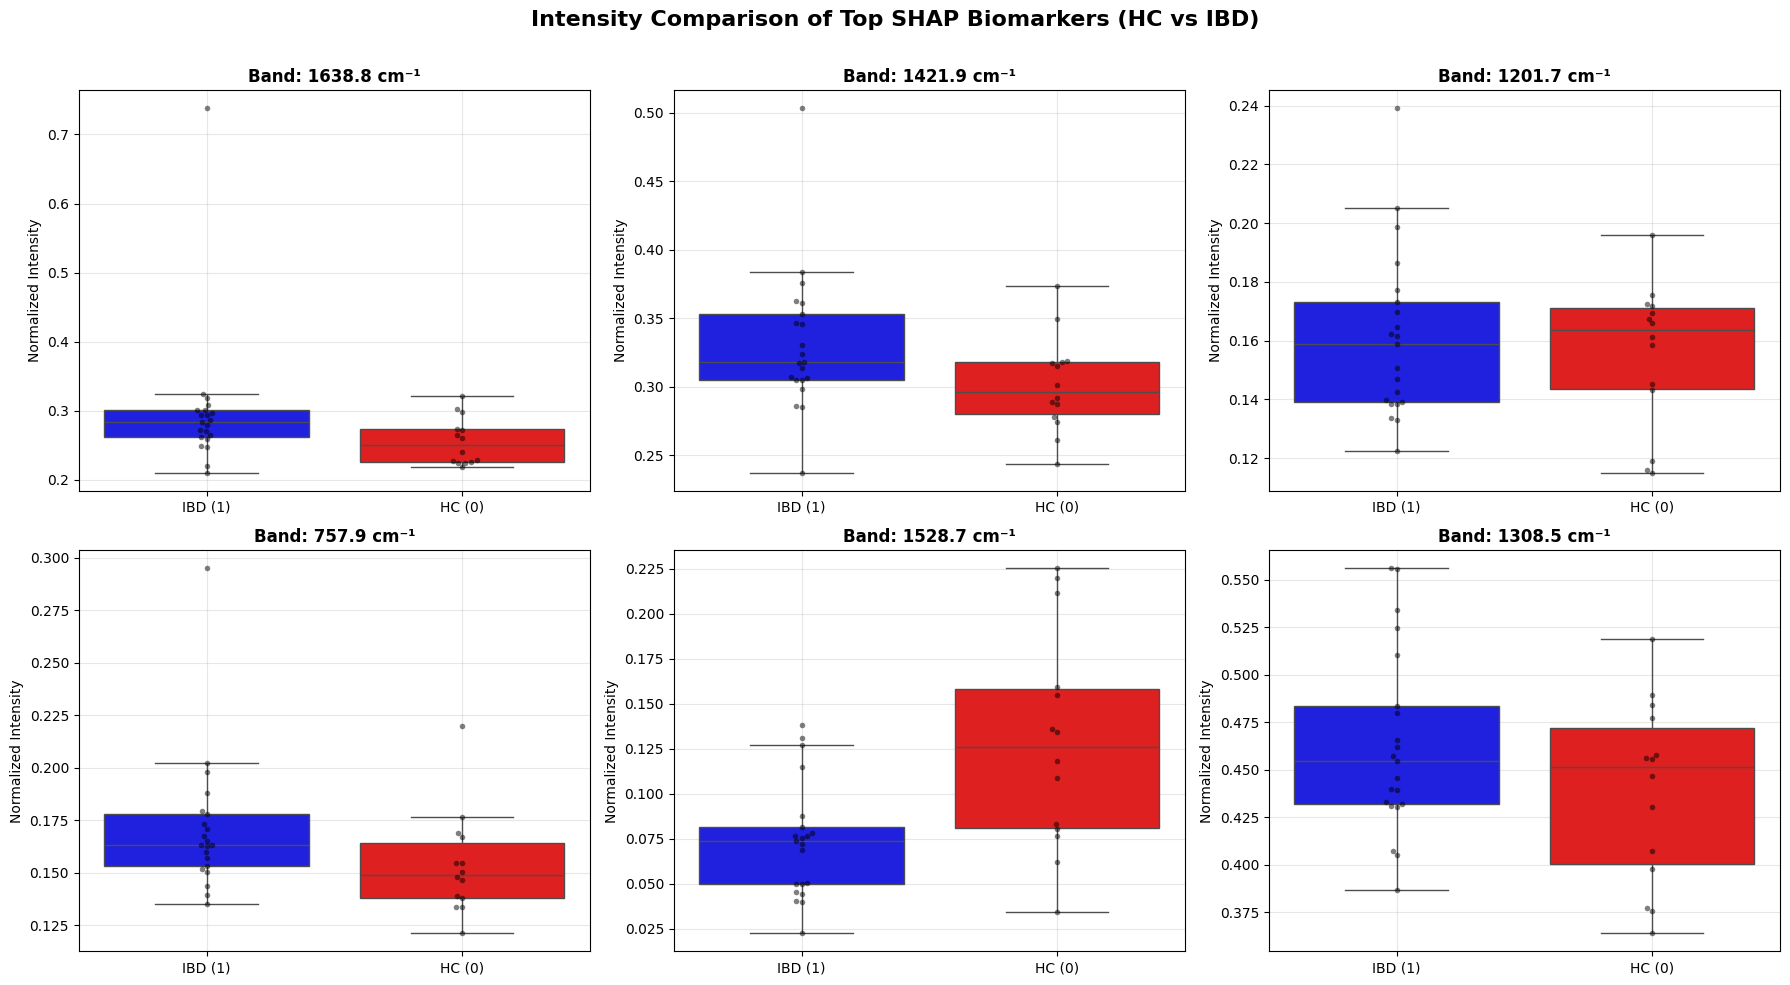

In [107]:
# ============================================================
# CELL 22 — Boxplot Comparison of Top Biomarker Intensities
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# We'll visualize the top 6 features from the SHAP top_indices
NUM_BOXPLOTS = min(6, len(top_indices))
selected_top_indices = top_indices[:NUM_BOXPLOTS]

# Prepare data for plotting
plot_data = []
Xte_np = Xte.squeeze().cpu().numpy()

for idx in selected_top_indices:
    shift_val = x_axis[idx]
    intensities = Xte_np[:, idx]
    for i in range(len(y_test)):
        plot_data.append({
            'Raman Shift': f"{shift_val:.1f} cm⁻¹",
            'Intensity': intensities[i],
            'Class': 'HC (0)' if y_test[i] == 0 else 'IBD (1)'
        })

df_boxplot = pd.DataFrame(plot_data)

# Setup the figure (2 rows, 3 columns grid)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, idx in enumerate(selected_top_indices):
    shift_val = x_axis[idx]
    shift_str = f"{shift_val:.1f} cm⁻¹"

    # Plot Boxplot
    sns.boxplot(
        x='Class', y='Intensity',
        hue='Class',
        data=df_boxplot[df_boxplot['Raman Shift'] == shift_str],
        ax=axes[i],
        palette=['blue', 'red'],
        showfliers=False, # Hide outliers since we'll overlay swarmplot
        legend=False
    )

    # Add swarmplot to see individual patient data points
    sns.swarmplot(
        x='Class', y='Intensity',
        data=df_boxplot[df_boxplot['Raman Shift'] == shift_str],
        ax=axes[i],
        color='black', alpha=0.5, size=4
    )

    axes[i].set_title(f"Band: {shift_str}", fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Normalized Intensity")
    axes[i].grid(alpha=0.3)

# Hide any unused subplots (if we have less than 6 top features)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Intensity Comparison of Top SHAP Biomarkers (HC vs IBD)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


### Intensity Analysis for all Biomarkers (IG + SHAP)

Total number of unique biomarkers identified by IG and SHAP: 12


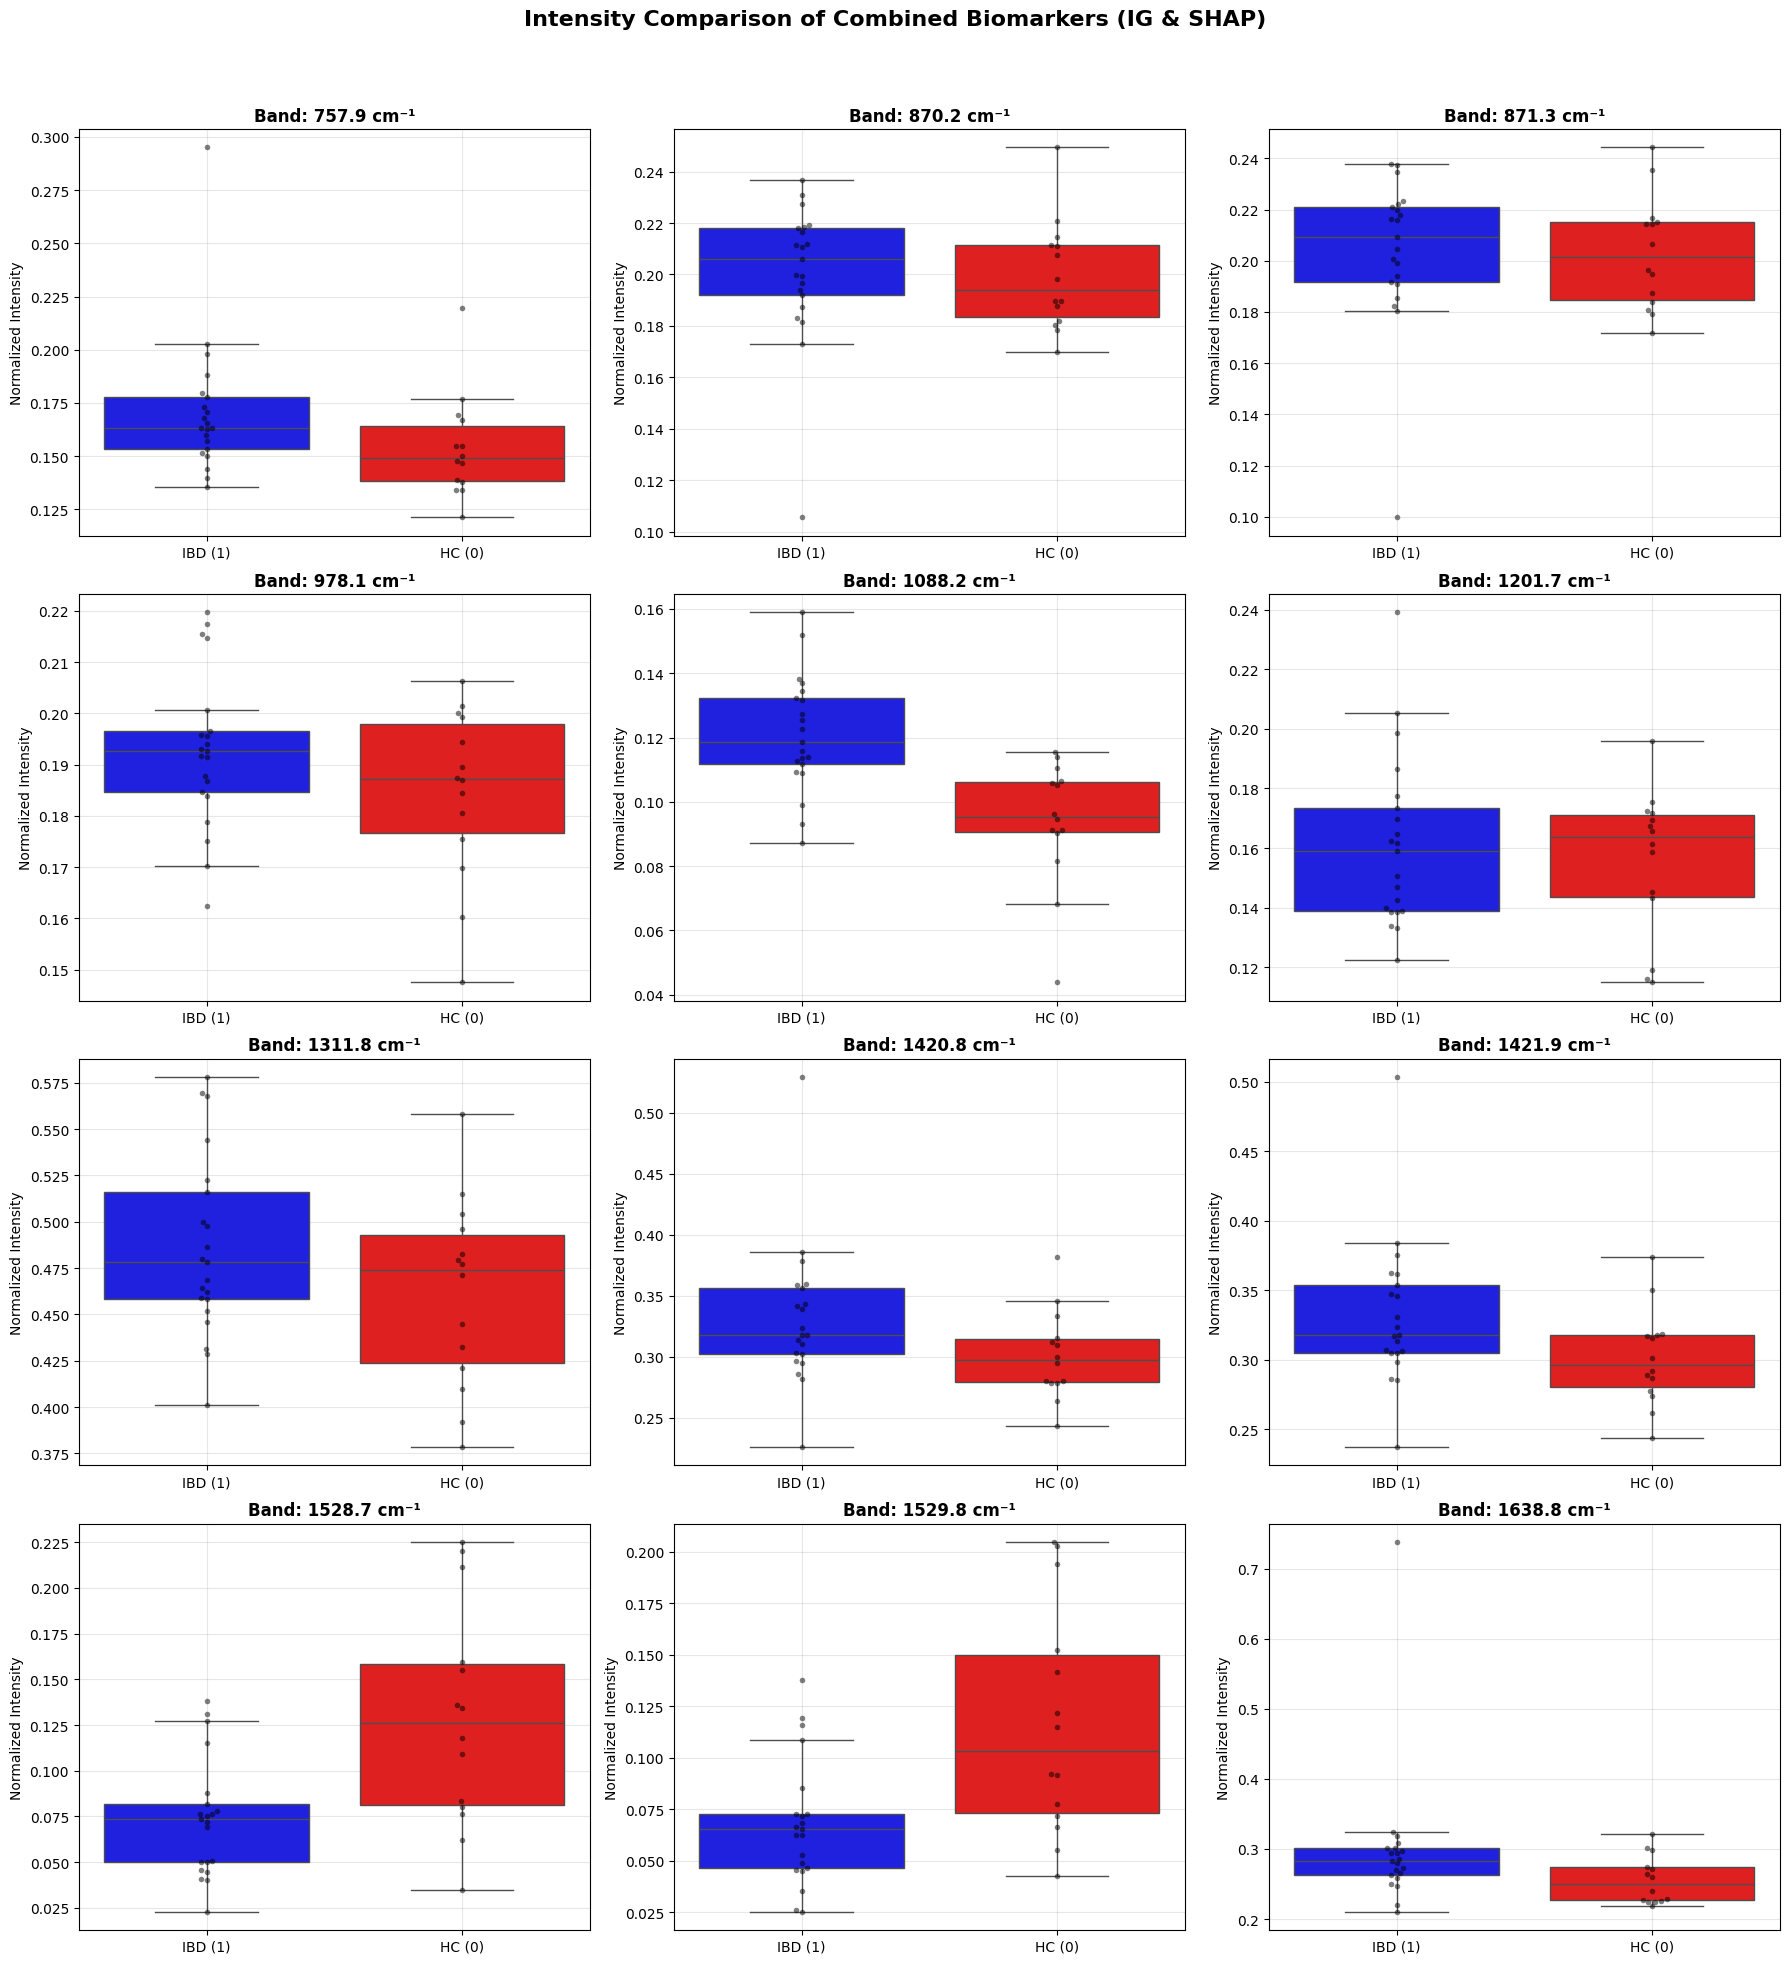

In [108]:
# ============================================================
# CELL 23 — Boxplot Comparison of Combined IG & SHAP Biomarkers
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Collect the indices of the top peaks found by IG and SHAP for both classes
ig_indices = [p['index'] for p in peaks_hc_ig] + [p['index'] for p in peaks_ibd_ig]
shap_indices = [p['index'] for p in peaks_hc_shap] + [p['index'] for p in peaks_ibd_shap]

# Merge and take unique indices to avoid duplicates if IG and SHAP find the same band
combined_top_indices = list(set(ig_indices + shap_indices))
# Sort the indices (optional, to have the plots in order of wavenumber)
combined_top_indices.sort()

print(f"Total number of unique biomarkers identified by IG and SHAP: {len(combined_top_indices)}")

# Prepare data for plotting
plot_data_combined = []
Xte_np = Xte.squeeze().cpu().numpy()

for idx in combined_top_indices:
    shift_val = x_axis[idx]
    intensities = Xte_np[:, idx]
    for i in range(len(y_test)):
        plot_data_combined.append({
            'Raman Shift': f"{shift_val:.1f} cm⁻¹",
            'Intensity': intensities[i],
            'Class': 'HC (0)' if y_test[i] == 0 else 'IBD (1)'
        })

df_boxplot_combined = pd.DataFrame(plot_data_combined)

# Dynamically calculate rows and columns for the grid
n_features = len(combined_top_indices)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, idx in enumerate(combined_top_indices):
    shift_val = x_axis[idx]
    shift_str = f"{shift_val:.1f} cm⁻¹"

    # Plot Boxplot
    sns.boxplot(
        x='Class', y='Intensity',
        hue='Class',
        data=df_boxplot_combined[df_boxplot_combined['Raman Shift'] == shift_str],
        ax=axes[i],
        palette=['blue', 'red'],
        showfliers=False,
        legend=False
    )

    # Add swarmplot to see individual patient data points
    sns.swarmplot(
        x='Class', y='Intensity',
        data=df_boxplot_combined[df_boxplot_combined['Raman Shift'] == shift_str],
        ax=axes[i],
        color='black', alpha=0.5, size=4
    )

    axes[i].set_title(f"Band: {shift_str}", fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Normalized Intensity")
    axes[i].grid(alpha=0.3)

# Hide any excess subplots if present
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Intensity Comparison of Combined Biomarkers (IG & SHAP)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.95 if n_rows == 1 else 0.92)
plt.show()


### Statistical Significance Analysis (p-value)

In [109]:
import pandas as pd
from scipy.stats import mannwhitneyu, ttest_ind

results = []

# Use the indices of the combined biomarkers (from IG and SHAP)
for idx in combined_top_indices:
    shift_val = x_axis[idx]

    # Extract the intensities for the two classes in the Test Set
    intensities_hc = Xte_np[y_test == 0, idx]
    intensities_ibd = Xte_np[y_test == 1, idx]

    # 1. Welch's T-test (assumes normal distribution but different variances)
    t_stat, p_val_t = ttest_ind(intensities_hc, intensities_ibd, equal_var=False)

    # 2. Mann-Whitney U test (non-parametric test, recommended if data is not perfectly normal)
    u_stat, p_val_mwu = mannwhitneyu(intensities_hc, intensities_ibd, alternative='two-sided')

    results.append({
        'Raman Shift (cm⁻¹)': f"{shift_val:.1f}",
        'Mean HC': f"{intensities_hc.mean():.4f}",
        'Mean IBD': f"{intensities_ibd.mean():.4f}",
        'p-value (T-test)': p_val_t,
        'p-value (Mann-Whitney)': p_val_mwu
    })

df_stats = pd.DataFrame(results)

# Function to interpret significance
def get_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

df_stats['Significance (MWU)'] = df_stats['p-value (Mann-Whitney)'].apply(get_stars)

# Sort by Mann-Whitney p-value (from most to least significant)
df_stats = df_stats.sort_values(by='p-value (Mann-Whitney)')

# Format p-values in scientific notation for better readability
df_stats['p-value (T-test)'] = df_stats['p-value (T-test)'].apply(lambda x: f"{x:.2e}")
df_stats['p-value (Mann-Whitney)'] = df_stats['p-value (Mann-Whitney)'].apply(lambda x: f"{x:.2e}")

print("="*70)
print(" STATISTICAL TESTS ON MAIN BIOMARKERS (Test Set)")
print("="*70)
display(df_stats)


 STATISTICAL TESTS ON MAIN BIOMARKERS (Test Set)


,Raman Shift (cm⁻¹),Mean HC,Mean IBD,p-value (T-test),p-value (Mann-Whitney),Significance (MWU)
4,1088.2,0.0939,0.1212,2.73e-04,2.59e-04,***
9,1528.7,0.1289,0.0736,5.54e-03,4.44e-03,**
10,1529.8,0.1164,0.0683,8.12e-03,6.06e-03,**
0,757.9,0.1538,0.1714,8.08e-02,3.53e-02,*
7,1420.8,0.3011,0.3317,6.35e-02,3.53e-02,*
8,1421.9,0.3014,0.3318,4.56e-02,6.17e-02,ns
11,1638.8,0.2560,0.2992,9.09e-02,6.65e-02,ns
6,1311.8,0.4616,0.4862,1.64e-01,2.45e-01,ns
3,978.1,0.1845,0.1928,1.49e-01,2.74e-01,ns
1,870.2,0.1993,0.2009,8.46e-01,3.72e-01,ns
